In [3]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [4]:
!ls ../data/datasets/

dataset_level_01_daily_total.parquet
dataset_level_02_daily_state.parquet
dataset_level_03_daily_cat.parquet
dataset_level_04_daily_dept.parquet
dataset_level_05_daily_state_cat.parquet
dataset_level_06_daily_store.parquet
dataset_level_07_daily_state_dept.parquet
dataset_level_08_daily_store_cat.parquet
dataset_level_09_daily_store_dept.parquet
dataset_level_10_weekly_item.parquet
dataset_level_11_weekly_item_state.parquet
dataset_level_12_weekly_item_store.parquet


# Data

In [5]:
LEVEL = 'level_01_daily_total'

# Granularidad temporal del nivel ('daily' o 'weekly'), embebida en el nombre
# (level_{id}_{grain}_{name}); se usa más abajo para adaptar estacionalidades
# (seasonal naive, SARIMA/ETS/Theta/TBATS/Prophet) al período correcto.
GRAIN = 'weekly' if '_weekly_' in LEVEL else 'daily'
SEASON_LENGTH = {"daily": 7, "weekly": 52}[GRAIN]

In [6]:
df = pd.read_parquet(f'../data/datasets/dataset_{LEVEL}.parquet')

df = df.sort_values("date").copy()

df.head()

,agg_id,item_id,dept_id,cat_id,store_id,state_id,date,sales,gross_sales,avg_sell_price,price_lag_7,price_change,price_vs_mean,has_event,has_event_2,snap,event_name_1,event_type_1,event_name_2,event_type_2,year,month,day,dayofweek,weekofyear,is_weekend,cum7,cum14,cum21,cum28,cum35,cum42,cum365,price_vs_max,days_since_release,days_since_event,days_to_event,days_to_closure,event_type_1_enc,event_type_2_enc,quarter,is_month_start,is_month_end,is_store_closed,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,price_volatility,days_since_thanksgiving,days_to_thanksgiving,days_since_newyear,days_to_newyear,zero_streak,pct_zero_28,pct_zero_90,adi_expanding,cv2_90,is_likely_stockout,lag1,lag2,lag3,lag7,lag14,lag21,lag28,lag35,lag42,lag56,lag91,lag182,lag364,rolling_mean_lag7_window_size7,rolling_std_lag7_window_size7,rolling_min_lag7_window_size7,rolling_max_lag7_window_size7,rolling_mean_lag7_window_size14,rolling_std_lag7_window_size14,rolling_min_lag7_window_size14,rolling_max_lag7_window_size14,rolling_mean_lag28_window_size7,rolling_std_lag28_window_size7,rolling_min_lag28_window_size7,rolling_max_lag28_window_size7,rolling_mean_lag28_window_size28,rolling_std_lag28_window_size28,rolling_min_lag28_window_size28,rolling_max_lag28_window_size28,rolling_mean_lag28_window_size91,rolling_std_lag28_window_size91,rolling_min_lag28_window_size91,rolling_max_lag28_window_size91,rolling_mean_lag28_window_size7_truediv_rolling_mean_lag28_window_size28,rolling_mean_lag91_window_size28,rolling_std_lag91_window_size28,rolling_min_lag91_window_size28,rolling_max_lag91_window_size28,rolling_mean_lag91_window_size91,rolling_std_lag91_window_size91,rolling_min_lag91_window_size91,rolling_max_lag91_window_size91,expanding_mean_lag91,rolling_mean_lag364_window_size28,rolling_std_lag364_window_size28,rolling_min_lag364_window_size28,rolling_max_lag364_window_size28,rolling_mean_lag364_window_size91,rolling_std_lag364_window_size91,rolling_min_lag364_window_size91,rolling_max_lag364_window_size91,seasonal_rolling_mean_lag364_season_length7_window_size8,rolling_mean_lag365_window_size28,rolling_mean_lag365_window_size91
0,TOTAL,TOTAL,TOTAL,TOTAL,TOTAL,TOTAL,2011-01-29,32631.0,81650.609375,2.502240,NaN,NaN,0.879217,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,195243.0,385314.0,564739.0,731960.0,905074.0,1090247.0,9667017.0,1.000000,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.000000,0.463258,0.886223,NaN,NaN,299.0,NaN,337.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TOTAL,TOTAL,TOTAL,TOTAL,TOTAL,TOTAL,2011-01-30,31749.0,78970.570312,2.487340,NaN,NaN,0.873981,0,0,0,NaN,NaN,NaN,NaN,2011,1,30,6,4,1,196230.0,389945.0,562273.0,728918.0,908201.0,1089915.0,9660456.0,0.994045,1,NaN,7.0,NaN,0,0,1,0,0,0,-0.781832,0.623490,0.0,1.000000,0.478434,0.878124,0.010536,NaN,298.0,NaN,336.0,0.0,0.0,0.0,0.000000,NaN,0,32631.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TOTAL,TOTAL,TOTAL,TOTAL,TOTAL,TOTAL,2011-01-31,23783.0,57706.910156,2.426393,NaN,NaN,0.852566,0,0,0,NaN,NaN,NaN,NaN,2011,1,31,0,5,0,198019.0,387966.0,562456.0,726375.0,908980.0,1091067.0,9661797.0,0.969688,2,NaN,6.0,NaN,0,0,1,0,1,0,0.000000,1.000000,0.0,1.000000,0.493468,0.869764,0.040186,NaN,297.0,NaN,335.0,0.0,0.0,0.0,0.500000,0.000375,0,31749.0,32631.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TOTAL,TOTAL,TOTAL,TOTAL,TOTAL,TOTAL,2011-02-01,25412.0,60761.199219,2.391044,NaN,NaN,0.840145,0,0,0,NaN,NaN,NaN,NaN,2011,2,1,1,5,0,195678.0,386624.0,557545.0,723835.0,906320.0,1089676.0,96662

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Columns: 115 entries, agg_id to rolling_mean_lag365_window_size91
dtypes: datetime64[ms](1), float32(79), float64(8), int16(1), int32(1), int8(15), str(10)
memory usage: 988.0 KB


# Variables

In [8]:
TARGET = "sales"

ID_COLS = ["agg_id", "date"]
CUM_COLS = [c for c in df.columns if c.startswith("cum") and c[3:].isdigit()]
LEAKY_COLS = ["gross_sales"] + CUM_COLS

FEATURES = [c for c in df.columns if c not in ID_COLS + LEAKY_COLS + [TARGET]]

# Dims estáticas candidatas: no todos los niveles tienen todas (p.ej. nivel item
# no tiene store_id/state_id), así que se filtran a las presentes en el dataset.
CATEGORICAL_FEATURES = [
    c for c in [
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2",
    ] if c in df.columns
]

NUMERICAL_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

print(len(FEATURES))

104


# Split

In [9]:
from src.data import date_split

TEST_DAYS = 28
VALID_DAYS = 365

data_split = date_split(df, valid_days=VALID_DAYS, test_days=TEST_DAYS)

train, valid, test = data_split.train, data_split.valid, data_split.test
first_date, last_date = data_split.first_date, data_split.last_date
valid_start, test_start = data_split.valid_start, data_split.test_start

data_split.log_summary()

2026-08-23 00:01:42.615 | INFO     | src.data.split:log_summary:38 - Train : 2011-01-29 to 2015-04-25 (1,547 days, 1,547 rows)
2026-08-23 00:01:42.618 | INFO     | src.data.split:log_summary:39 - Valid : 2015-04-25 to 2016-04-24 (365 days, 365 rows)
2026-08-23 00:01:42.619 | INFO     | src.data.split:log_summary:40 - Test  : 2016-04-24 to 2016-05-22 (28 days, 29 rows)


In [10]:
from src.data import build_feature_matrices

X_train, y_train, X_valid, y_valid, X_test, y_test = build_feature_matrices(
    df, data_split, FEATURES, CATEGORICAL_FEATURES, TARGET,
)

print(f"Cantidad features: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categoricas)")


Cantidad features: 104 (9 categoricas)


# Comparación de modelos

Antes de invertir tiempo en selección de features, se evalúan varios modelos con hiperparámetros por defecto sobre el set de validación. El objetivo es elegir la familia de modelo con mejor desempeño (WAPE/WRMSSE) para después iterar sobre ella (feature selection, tuning, etc.).

In [11]:
import time

from src.evaluation import evaluate_predictions

model_results = []
predictions_valid = {}

def evaluate_model(name, y_pred_valid, fit_time=None, category=None):
    result = evaluate_predictions(train, valid, y_valid, y_pred_valid, name, fit_time=fit_time, category=category)
    model_results.append(result)
    predictions_valid[name] = y_pred_valid
    return result

## Baseline models

In [12]:
from src.modeling import naive_last_value, seasonal_naive, drift, historical_mean, moving_average

In [13]:
t0 = time.perf_counter()
y_pred_naive = naive_last_value(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Naive (last value)", y_pred_naive, fit_time=fit_time, category="Naive")

2026-08-23 00:01:43.216 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Naive (last value) [Naive] | WAPE: 15.29% | WRMSSE: 1.4189 | MAE: 6024.282 | RMSE: 8116.685 | MAPE: 13.79% | SMAPE: 15.32% | Bias: -12.88% | RMSLE: 0.2002 | TS: 307.58 | SPEC: 9234751.190 | MASE: 1.4608 | fit: 0.01s


{'model': 'Naive (last value)',
 'category': 'Naive',
 'wape': 0.15288016292103154,
 'wrmsse': 1.4189042441984323,
 'mae': 6024.282191780822,
 'rmse': 8116.684982774004,
 'mape': 0.13788202746674325,
 'smape': 0.1532125524603978,
 'bias': -0.12882969027358077,
 'rmsle': 0.20017690428553758,
 'tracking_signal': 307.57971506182963,
 'spec': 9234751.189726027,
 'mase': 1.4607692219668174,
 'fit_time': 0.01282560500112595}

In [14]:
t0 = time.perf_counter()
y_pred_seasonal_short = seasonal_naive(train, valid, TARGET, season_length=SEASON_LENGTH)
fit_time = time.perf_counter() - t0
evaluate_model(f"Seasonal naive ({SEASON_LENGTH}{GRAIN[0]})", y_pred_seasonal_short, fit_time=fit_time, category="Naive")

if GRAIN == "daily":
    t0 = time.perf_counter()
    y_pred_seasonal_year = seasonal_naive(train, valid, TARGET, season_length=365)
    fit_time = time.perf_counter() - t0
    evaluate_model("Seasonal naive (365d)", y_pred_seasonal_year, fit_time=fit_time, category="Naive")

2026-08-23 00:01:43.312 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Seasonal naive (7d) [Naive] | WAPE: 12.30% | WRMSSE: 1.0051 | MAE: 4846.384 | RMSE: 5749.758 | MAPE: 11.97% | SMAPE: 12.90% | Bias: -11.12% | RMSLE: 0.1512 | TS: 330.00 | SPEC: 6667317.364 | MASE: 1.1752 | fit: 0.02s
2026-08-23 00:01:43.369 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Seasonal naive (365d) [Naive] | WAPE: 13.70% | WRMSSE: 1.1861 | MAE: 5396.570 | RMSE: 6784.924 | MAPE: 13.14% | SMAPE: 14.02% | Bias: -8.76% | RMSLE: 0.1742 | TS: 233.43 | SPEC: 3666949.825 | MASE: 1.3086 | fit: 0.01s


### Drift

In [15]:
t0 = time.perf_counter()
y_pred_drift = drift(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Drift", y_pred_drift, fit_time=fit_time, category="Naive")

2026-08-23 00:01:43.463 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -             Drift [Naive] | WAPE: 14.97% | WRMSSE: 1.3936 | MAE: 5898.315 | RMSE: 7971.985 | MAPE: 13.51% | SMAPE: 14.96% | Bias: -12.35% | RMSLE: 0.1960 | TS: 301.07 | SPEC: 8620680.895 | MASE: 1.4302 | fit: 0.03s


{'model': 'Drift',
 'category': 'Naive',
 'wape': 0.14968345833840035,
 'wrmsse': 1.3936088495787238,
 'mae': 5898.315224441333,
 'rmse': 7971.98547223084,
 'mape': 0.13510453965599273,
 'smape': 0.14962993800492158,
 'bias': -0.12346642175608759,
 'rmsle': 0.19601404118527552,
 'tracking_signal': 301.0703015632474,
 'spec': 8620680.894627757,
 'mase': 1.4302247250431712,
 'fit_time': 0.027889955999853555}

### Historical mean

In [16]:
t0 = time.perf_counter()
y_pred_mean = historical_mean(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Historical mean", y_pred_mean, fit_time=fit_time, category="Naive")

2026-08-23 00:01:43.552 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -   Historical mean [Naive] | WAPE: 17.35% | WRMSSE: 1.5693 | MAE: 6838.139 | RMSE: 8977.160 | MAPE: 15.64% | SMAPE: 17.69% | Bias: -16.14% | RMSLE: 0.2259 | TS: 339.44 | SPEC: 14985414.568 | MASE: 1.6581 | fit: 0.01s


{'model': 'Historical mean',
 'category': 'Naive',
 'wape': 0.17353367756051466,
 'wrmsse': 1.5693267174272996,
 'mae': 6838.139255136986,
 'rmse': 8977.16012372913,
 'mape': 0.15641482464241138,
 'smape': 0.17692989330587172,
 'bias': -0.16138075722841796,
 'rmsle': 0.22594242244310445,
 'tracking_signal': 339.438299334327,
 'spec': 14985414.567636989,
 'mase': 1.6581134550860743,
 'fit_time': 0.010686650002753595}

### Moving average

In [17]:
MA_WINDOWS = {"daily": [7, 14, 21, 28, 35], "weekly": [2, 3, 4, 6, 8,]}[GRAIN]

for window in MA_WINDOWS:
    t0 = time.perf_counter()
    y_pred_ma = moving_average(train, valid, TARGET, window=window)
    fit_time = time.perf_counter() - t0
    evaluate_model(f"Moving average ({window}{GRAIN[0]})", y_pred_ma, fit_time=fit_time, category="Naive")

2026-08-23 00:01:43.633 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Moving average (7d) [Naive] | WAPE: 14.41% | WRMSSE: 1.3483 | MAE: 5678.954 | RMSE: 7712.675 | MAPE: 13.05% | SMAPE: 14.34% | Bias: -11.18% | RMSLE: 0.1886 | TS: 283.05 | SPEC: 6777246.906 | MASE: 1.3770 | fit: 0.01s
2026-08-23 00:01:43.681 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Moving average (14d) [Naive] | WAPE: 13.46% | WRMSSE: 1.2564 | MAE: 5302.704 | RMSE: 7187.174 | MAPE: 12.35% | SMAPE: 13.30% | Bias: -8.64% | RMSLE: 0.1744 | TS: 234.29 | SPEC: 3829618.837 | MASE: 1.2858 | fit: 0.00s
2026-08-23 00:01:43.736 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - Moving average (21d) [Naive] | WAPE: 13.07% | WRMSSE: 1.2092 | MAE: 5151.625 | RMSE: 6917.047 | MAPE: 12.15% | SMAPE: 12.90% | Bias: -7.08% | RMSLE: 0.1676 | TS: 197.70 | SPEC: 2438998.196 | MASE: 1.2492 | fit: 0.01s
2026-08-23 00:01:43.788 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - M

## Modelos estadísticos clásicos

Familias de forecasting estadístico clásico, ajustadas serie por serie (sin usar la matriz de features de ML). SARIMA es el modelo más citado en la literatura académica; ETS/Holt-Winters es rápido y robusto (base de benchmarks M4/M5); Theta ganó la M3 pese a su simplicidad; TBATS extiende ETS para estacionalidades múltiples; Prophet (Meta) es popular en industria por ser fácil de tunear.

In [18]:
from src.modeling import fit_sarima, fit_ets, fit_theta, fit_tbats, fit_prophet

### SARIMA

In [19]:
t0 = time.perf_counter()
y_pred_sarima = fit_sarima(train, valid, TARGET, seasonal_order=(1, 1, 1, SEASON_LENGTH))
fit_time = time.perf_counter() - t0

evaluate_model("SARIMA", y_pred_sarima, fit_time=fit_time, category="Statistical")

2026-08-23 00:01:52.898 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -      SARIMA [Statistical] | WAPE: 15.03% | WRMSSE: 1.1990 | MAE: 5921.894 | RMSE: 6858.768 | MAPE: 14.57% | SMAPE: 15.99% | Bias: -14.22% | RMSLE: 0.1832 | TS: 345.44 | SPEC: 10158122.127 | MASE: 1.4359 | fit: 8.93s


{'model': 'SARIMA',
 'category': 'Statistical',
 'wape': 0.1502818213055076,
 'wrmsse': 1.1990036916103592,
 'mae': 5921.893871259151,
 'rmse': 6858.76816407873,
 'mape': 0.14566509987808737,
 'smape': 0.1599318450783883,
 'bias': -0.14222747877502673,
 'rmsle': 0.18321856268723727,
 'tracking_signal': 345.4378533738346,
 'spec': 10158122.126988485,
 'mase': 1.4359420803181426,
 'fit_time': 8.93206865600223}

### ETS (Holt-Winters)

In [20]:
t0 = time.perf_counter()
y_pred_ets = fit_ets(train, valid, TARGET, seasonal_periods=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("ETS (Holt-Winters)", y_pred_ets, fit_time=fit_time, category="Statistical")

2026-08-23 00:01:57.959 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - ETS (Holt-Winters) [Statistical] | WAPE: 10.02% | WRMSSE: 0.8597 | MAE: 3946.952 | RMSE: 4917.616 | MAPE: 9.64% | SMAPE: 10.23% | Bias: -8.51% | RMSLE: 0.1256 | TS: 310.16 | SPEC: 4319266.184 | MASE: 0.9571 | fit: 4.99s


{'model': 'ETS (Holt-Winters)',
 'category': 'Statistical',
 'wape': 0.10016308287049562,
 'wrmsse': 0.8596646002422025,
 'mae': 3946.9520759359616,
 'rmse': 4917.616378651475,
 'mape': 0.0963711580065796,
 'smape': 0.1023190845363447,
 'bias': -0.08511320147036021,
 'rmsle': 0.12562681967275516,
 'tracking_signal': 310.157371821794,
 'spec': 4319266.184309474,
 'mase': 0.9570577754427768,
 'fit_time': 4.989558280001802}

### Theta

In [21]:
t0 = time.perf_counter()
y_pred_theta = fit_theta(train, valid, TARGET, period=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("Theta", y_pred_theta, fit_time=fit_time, category="Statistical")

2026-08-23 00:02:02.696 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -       Theta [Statistical] | WAPE: 11.34% | WRMSSE: 0.9524 | MAE: 4468.443 | RMSE: 5448.239 | MAPE: 10.79% | SMAPE: 11.55% | Bias: -10.27% | RMSLE: 0.1376 | TS: 330.48 | SPEC: 6145099.303 | MASE: 1.0835 | fit: 4.67s


{'model': 'Theta',
 'category': 'Statistical',
 'wape': 0.1133971216508803,
 'wrmsse': 0.9524244041032062,
 'mae': 4468.442782295226,
 'rmse': 5448.238589475152,
 'mape': 0.10786378124424878,
 'smape': 0.11551696845554386,
 'bias': -0.10267363582399741,
 'rmsle': 0.13763498639872682,
 'tracking_signal': 330.4834949086041,
 'spec': 6145099.302544448,
 'mase': 1.0835089523864254,
 'fit_time': 4.672078157000215}

### TBATS

In [22]:
t0 = time.perf_counter()
y_pred_tbats = fit_tbats(train, valid, TARGET, season_length=(SEASON_LENGTH,))
fit_time = time.perf_counter() - t0

evaluate_model("TBATS", y_pred_tbats, fit_time=fit_time, category="Statistical")

/home/njimenez/workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
2026-08-23 00:02:24.340 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -       TBATS [Statistical] | WAPE: 19.64% | WRMSSE: 1.5366 | MAE: 7738.789 | RMSE: 8789.949 | MAPE: 19.01% | SMAPE: 21.50% | Bias: -19.24% | RMSLE: 0.2423 | TS: 357.57 | SPEC: 17873502.998 | MASE: 1.8765 | fit: 21.56s


{'model': 'TBATS',
 'category': 'Statistical',
 'wape': 0.1963897646714873,
 'wrmsse': 1.5365997260616895,
 'mae': 7738.789253970037,
 'rmse': 8789.948984968541,
 'mape': 0.19009789824320827,
 'smape': 0.2149570153186743,
 'bias': -0.1923923940040812,
 'rmsle': 0.24230916426932597,
 'tracking_signal': 357.57069075853394,
 'spec': 17873502.997680526,
 'mase': 1.8765032575848275,
 'fit_time': 21.564818402999663}

### Prophet

In [23]:
t0 = time.perf_counter()
y_pred_prophet = fit_prophet(train, valid, TARGET, weekly_seasonality=(GRAIN == "daily"))
fit_time = time.perf_counter() - t0

evaluate_model("Prophet", y_pred_prophet, fit_time=fit_time, category="Statistical")

00:02:29 - cmdstanpy - INFO - Chain [1] start processing
00:02:29 - cmdstanpy - INFO - Chain [1] done processing
2026-08-23 00:02:30.276 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -     Prophet [Statistical] | WAPE: 11.06% | WRMSSE: 0.9219 | MAE: 4359.142 | RMSE: 5273.896 | MAPE: 10.56% | SMAPE: 11.30% | Bias: -9.75% | RMSLE: 0.1334 | TS: 321.75 | SPEC: 4583947.035 | MASE: 1.0570 | fit: 5.87s


{'model': 'Prophet',
 'category': 'Statistical',
 'wape': 0.1106233613890748,
 'wrmsse': 0.9219469605476287,
 'mae': 4359.1420448405215,
 'rmse': 5273.895740454607,
 'mape': 0.10562944142063073,
 'smape': 0.11301434995172907,
 'bias': -0.09751580825444178,
 'rmsle': 0.13344674462805597,
 'tracking_signal': 321.7518394481408,
 'spec': 4583947.0354225915,
 'mase': 1.0570056864155946,
 'fit_time': 5.865139318000729}

## Modelos Machine Learning

In [24]:
from src.modeling import fit_lightgbm, fit_xgboost, fit_catboost, catboost_features, fit_histgb, histgb_features, fit_ridge

RANDOM_STATE = 42

### LightGBM

In [25]:
t0 = time.perf_counter()
lgbm_model = fit_lightgbm(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM", lgbm_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-23 00:02:31.078 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -             LightGBM [ML] | WAPE: 5.75% | WRMSSE: 0.5373 | MAE: 2266.927 | RMSE: 3073.683 | MAPE: 5.44% | SMAPE: 5.63% | Bias: -4.24% | RMSLE: 0.0734 | TS: 269.01 | SPEC: 775272.068 | MASE: 0.5497 | fit: 0.68s


{'model': 'LightGBM',
 'category': 'ML',
 'wape': 0.05752854269013318,
 'wrmsse': 0.5373205541678677,
 'mae': 2266.927040274596,
 'rmse': 3073.682872387138,
 'mape': 0.05437961894255934,
 'smape': 0.05631478958705733,
 'bias': -0.04239875599523278,
 'rmsle': 0.07343923410374217,
 'tracking_signal': 269.006396035723,
 'spec': 775272.067702342,
 'mase': 0.5496849489214533,
 'fit_time': 0.6800793299989891}

### XGBoost

In [26]:
t0 = time.perf_counter()
xgb_model = fit_xgboost(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("XGBoost", xgb_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-23 00:02:32.190 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -              XGBoost [ML] | WAPE: 5.65% | WRMSSE: 0.5370 | MAE: 2227.272 | RMSE: 3071.931 | MAPE: 5.37% | SMAPE: 5.56% | Bias: -4.09% | RMSLE: 0.0734 | TS: 264.02 | SPEC: 775095.660 | MASE: 0.5401 | fit: 1.01s


{'model': 'XGBoost',
 'category': 'ML',
 'wape': 0.05652220586055932,
 'wrmsse': 0.5370142350878998,
 'mae': 2227.272078339041,
 'rmse': 3071.9306079292096,
 'mape': 0.05369778759561928,
 'smape': 0.05564519428771827,
 'bias': -0.04088437841616156,
 'rmsle': 0.07341234758617741,
 'tracking_signal': 264.0165558774125,
 'spec': 775095.6603234696,
 'mase': 0.5400694053513402,
 'fit_time': 1.0083794009988196}

### CatBoost

In [27]:
t0 = time.perf_counter()
catboost_model = fit_catboost(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_cb = catboost_features(X_valid, CATEGORICAL_FEATURES)

evaluate_model("CatBoost", catboost_model.predict(X_valid_cb), fit_time=fit_time, category="ML")

2026-08-23 00:02:40.872 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -             CatBoost [ML] | WAPE: 6.14% | WRMSSE: 0.5723 | MAE: 2420.804 | RMSE: 3273.808 | MAPE: 5.80% | SMAPE: 6.06% | Bias: -5.08% | RMSLE: 0.0790 | TS: 302.00 | SPEC: 1000062.894 | MASE: 0.5870 | fit: 8.59s


{'model': 'CatBoost',
 'category': 'ML',
 'wape': 0.06143352784446673,
 'wrmsse': 0.5723050156587688,
 'mae': 2420.8039859485193,
 'rmse': 3273.80761961703,
 'mape': 0.058032209665237124,
 'smape': 0.060589552975364634,
 'bias': -0.05082977964507731,
 'rmsle': 0.07895657288108043,
 'tracking_signal': 301.99909107326744,
 'spec': 1000062.8943714054,
 'mase': 0.5869970633037115,
 'fit_time': 8.593173750999995}

### HistGradientBoosting (sklearn)

In [28]:
t0 = time.perf_counter()
hgb_model = fit_histgb(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_hgb = histgb_features(X_valid, hgb_model.high_cardinality_features_)

evaluate_model("HistGradientBoosting", hgb_model.predict(X_valid_hgb), fit_time=fit_time, category="ML")

2026-08-23 00:02:42.390 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - HistGradientBoosting [ML] | WAPE: 6.11% | WRMSSE: 0.5673 | MAE: 2408.993 | RMSE: 3245.364 | MAPE: 5.78% | SMAPE: 6.01% | Bias: -4.81% | RMSLE: 0.0779 | TS: 287.45 | SPEC: 1088865.131 | MASE: 0.5841 | fit: 1.42s


{'model': 'HistGradientBoosting',
 'category': 'ML',
 'wape': 0.061133784105168086,
 'wrmsse': 0.5673327162113524,
 'mae': 2408.9925067071786,
 'rmse': 3245.3641299173432,
 'mape': 0.05781222525444598,
 'smape': 0.06012547022397513,
 'bias': -0.0481448203237635,
 'rmsle': 0.07791957876921846,
 'tracking_signal': 287.4492340919579,
 'spec': 1088865.1313884298,
 'mase': 0.5841330133152844,
 'fit_time': 1.4189014519979537}

### Ridge (sklearn)

Modelo lineal de referencia; solo usa las features numéricas (no maneja categóricas de alta cardinalidad).

In [29]:
t0 = time.perf_counter()
ridge_model = fit_ridge(X_train, y_train, NUMERICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("Ridge", ridge_model.predict(X_valid[NUMERICAL_FEATURES]), fit_time=fit_time, category="ML")

2026-08-23 00:02:42.518 | INFO     | src.evaluation.metrics:evaluate_predictions:326 -                Ridge [ML] | WAPE: 6.19% | WRMSSE: 0.5928 | MAE: 2439.211 | RMSE: 3390.778 | MAPE: 6.03% | SMAPE: 6.24% | Bias: -3.23% | RMSLE: 0.0853 | TS: 190.65 | SPEC: 297503.525 | MASE: 0.5915 | fit: 0.05s


{'model': 'Ridge',
 'category': 'ML',
 'wape': 0.06190064532614248,
 'wrmsse': 0.5927530776847597,
 'mae': 2439.210870612701,
 'rmse': 3390.7784995420184,
 'mape': 0.06028636693251007,
 'smape': 0.06239190250939521,
 'bias': -0.03233182062636322,
 'rmsle': 0.08534241356012813,
 'tracking_signal': 190.64606623153597,
 'spec': 297503.52450853784,
 'mase': 0.5914603685961518,
 'fit_time': 0.05450777499936521}

### Red neuronal (desde Colab)

Resultado entrenado aparte en `02_1_red_neuronal.ipynb` (Google Colab, con GPU). Se pega acá el JSON impreso al final de ese notebook (`evaluate_predictions` sobre el mismo set de validación) para incorporarlo a `model_results` y compararlo en la misma tabla.

In [30]:
import json

# Pegar aca el JSON impreso al final de 02_1_red_neuronal.ipynb
nn_result_json = """
{
  "model": "Red neuronal (PyTorch)",
  "category": "Neural Network",
  "wape": 0.10028197523732978,
  "wrmsse": 0.6648106210840594,
  "mae": 56.451958003855964,
  "rmse": 101.11262700533668,
  "mape": 0.14361555839435278,
  "smape": 0.13450871897523384,
  "bias": -0.01973313975149749,
  "rmsle": 0.18986484887682267,
  "tracking_signal": 5027.640505260812,
  "spec": 24816.267370544832,
  "mase": 0.6779046862289563,
  "fit_time": 27.297044813000014
}
"""

nn_result = json.loads(nn_result_json)
if nn_result.get("model"):
    model_results.append(nn_result)
    print(f"Agregado: {nn_result['model']}")
else:
    print("Pega el JSON de 02_1_red_neuronal.ipynb en nn_result_json antes de correr esta celda")

Agregado: Red neuronal (PyTorch)


## Resultados

In [31]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, order=df_sorted[y], ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [32]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse")
results_df

,model,category,wape,wrmsse,mae,rmse,mape,smape,bias,rmsle,tracking_signal,spec,mase,fit_time
16,XGBoost,ML,0.056522,0.537014,2227.272078,3071.930608,0.053698,0.055645,-0.040884,0.073412,264.016556,7.750957e+05,0.540069,1.008379
15,LightGBM,ML,0.057529,0.537321,2266.927040,3073.682872,0.054380,0.056315,-0.042399,0.073439,269.006396,7.752721e+05,0.549685,0.680079
18,HistGradientBoosting,ML,0.061134,0.567333,2408.992507,3245.364130,0.057812,0.060125,-0.048145,0.077920,287.449234,1.088865e+06,0.584133,1.418901
17,CatBoost,ML,0.061434,0.572305,2420.803986,3273.807620,0.058032,0.060590,-0.050830,0.078957,301.999091,1.000063e+06,0.586997,8.593174
19,Ridge,ML,0.061901,0.592753,2439.210871,3390.778500,0.060286,0.062392,-0.032332,0.085342,190.646066,2.975035e+05,0.591460,0.054508
20,Red neuronal (PyTorch),Neural Network,0.100282,0.664811,56.451958,101.112627,0.143616,0.134509,-0.019733,0.189865,5027.640505,2.481627e+04,0.677905,27.297045
11,ETS (Holt-Winters),Statistical,0.100163,0.859665,3946.952076,4917.616379,0.096371,0.102319,-0.085113,0.125627,310.157372,4.319266e+06,0.957058,4.989558
14,Prophet,Statistical,0.110623,0.921947,4359.142045,5273.895740,0.105629,0.113014,-0.097516,0.133447,321.751839,4.583947e+06,1.057006,5.865139
12,Theta,Statistical,0.113397,0.952424,4468.442782,5448.238589,0.107864,0.115517,-0.102674,0.137635,330.483495,6.145099e+06,1.083509,4.672078
1,Seasonal naive (7d),Naive,0.122988,1.005134,4846.383562,5749.757859,0.119674,0.128972,-0.111195,0.151209,330.000707,6.667317e+06,1.175152,0.023644


### Métricas por serie para todos los modelos

`build_series_metrics` da WAPE/bias/RMSLE/tracking signal/WRMSSE/MASE/SPEC por serie para un modelo. `build_all_series_metrics` lo corre para todos los modelos de `predictions_valid` (mismo set de validación) y los concatena en un único DataFrame con columna `model`, para comparar múltiples métricas a nivel de serie entre modelos (no solo el agregado de `results_df`).

In [33]:
from src.evaluation import build_all_series_metrics

series_metrics_df = build_all_series_metrics(train, valid, y_valid, predictions_valid, target_col=TARGET)
series_metrics_df.sort_values(["model", "gross_sales"], ascending=[True, False]).head(20)

,agg_id,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec,model
17,TOTAL,365,364,14382919.0,13651835.0,731084.0,883592.0,44458148.0,1.0,0.061433,-0.050830,0.078956,302.000991,0.619880,0.586996,1.000077e+06,CatBoost
3,TOTAL,365,364,14382919.0,12607113.0,1775806.0,2152884.0,44458148.0,1.0,0.149683,-0.123466,0.196014,301.070188,1.540914,1.430224,8.620661e+06,Drift
11,TOTAL,365,364,14382919.0,13158742.0,1224177.0,1440639.0,44458148.0,1.0,0.100163,-0.085113,0.125627,310.157232,0.905769,0.957059,4.319292e+06,ETS (Holt-Winters)
18,TOTAL,365,364,14382919.0,13690462.0,692457.0,879275.0,44458148.0,1.0,0.061133,-0.048144,0.077919,287.449097,0.614126,0.584128,1.088848e+06,HistGradientBoosting
4,TOTAL,365,364,14382919.0,12061868.0,2321051.0,2495867.0,44458148.0,1.0,0.173530,-0.161376,0.225938,339.434599,1.729892,1.658078,1.498438e+07,Historical mean
15,TOTAL,365,364,14382919.0,13773104.0,609815.0,827423.0,44458148.0,1.0,0.057528,-0.042399,0.073439,269.006874,0.582268,0.549681,7.752612e+05,LightGBM
6,TOTAL,365,364,14382919.0,13140400.0,1242519.0,1935535.0,44458148.0,1.0,0.134572,-0.086389,0.174411,234.312185,1.386205,1.285833,3.830700e+06,Moving average (14d)
7,TOTAL,365,364,14382919.0,13364624.0,1018295.0,1880309.0,44458148.0,1.0,0.130732,-0.070799,0.167553,197.668402,1.329018,1.249144,2.438045e+06,Moving average (21d)
8,TOTAL,365,364,14382919.0,13402844.0,980075.0,1872783.0,44458148.0,1.0,0.130209,-0.068142,0.166537,191.013788,1.319899,1.244145,2.232432e+06,Moving average (28d)
9,TOTAL,365,364,14382919.0,13213928.0,1168991.0,1914723.0,44458148.0,1.0,0.133125,-0.081276,0.171996,222.842529,1.366781,1.272007,3.339197e+06,Moving average (35d)


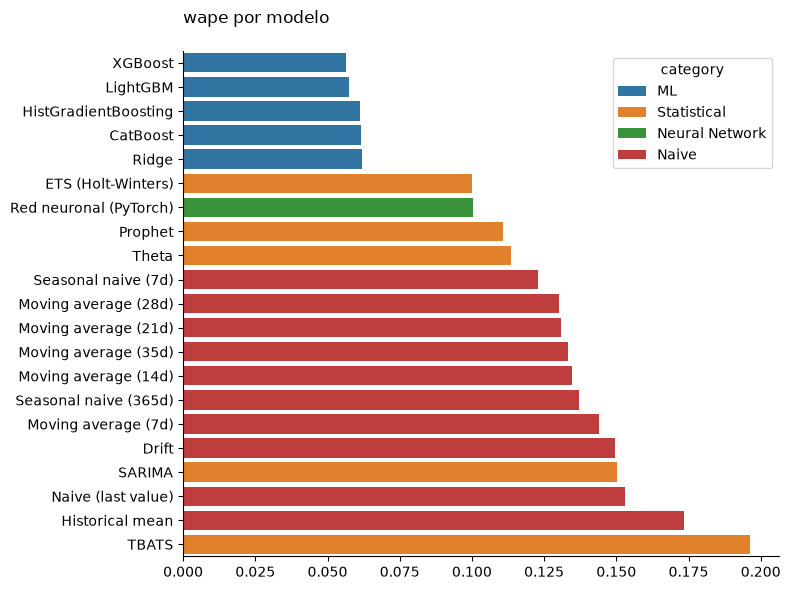

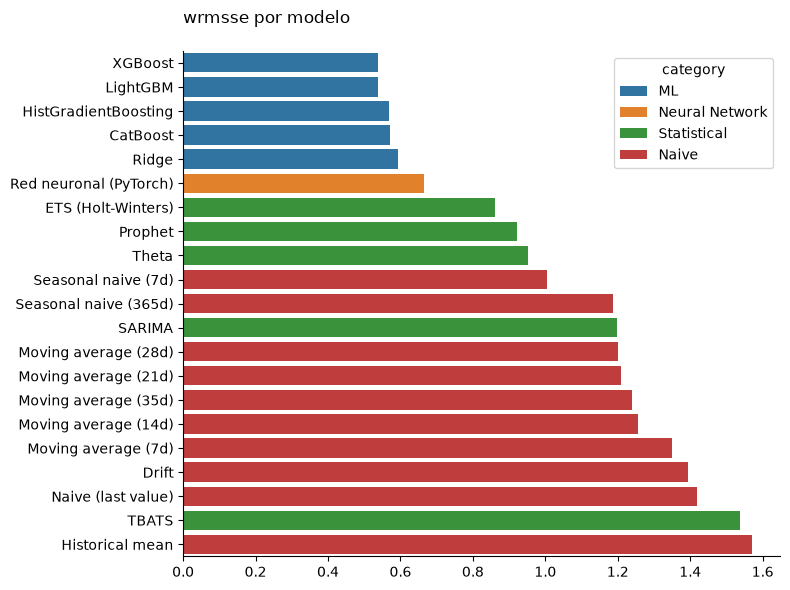

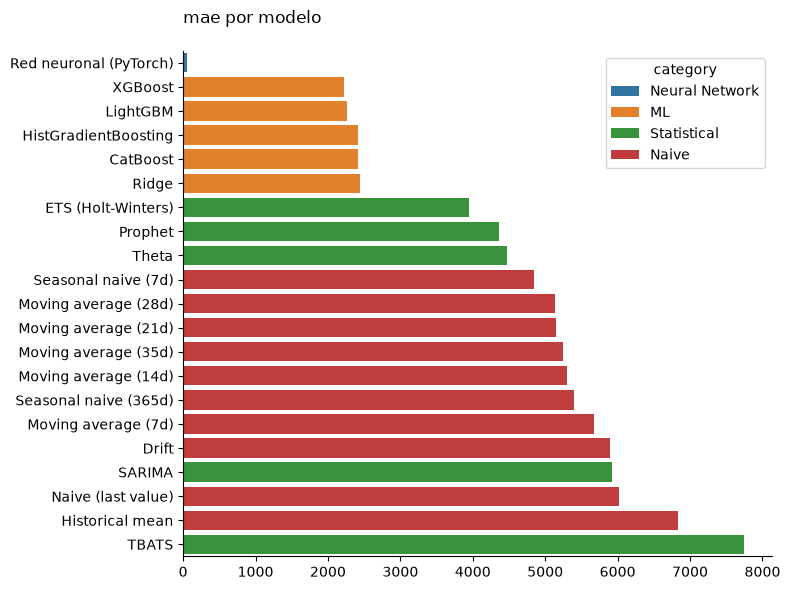

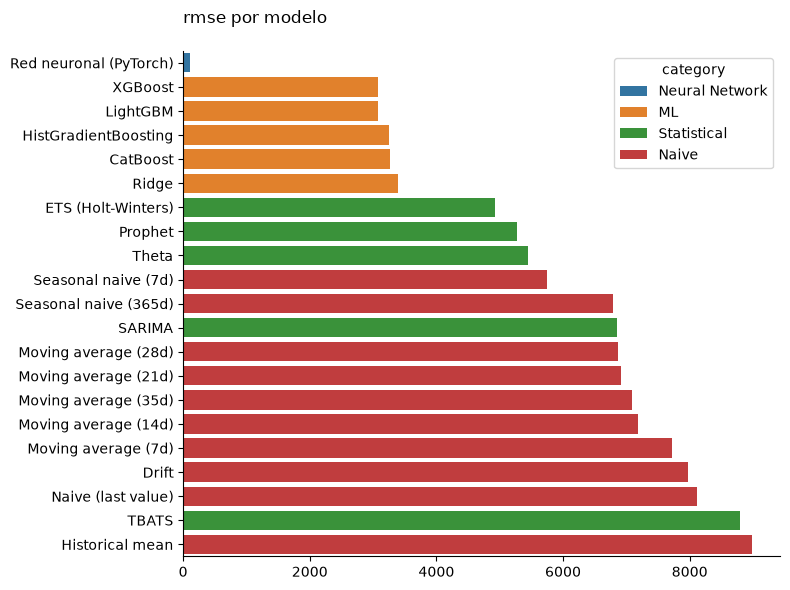

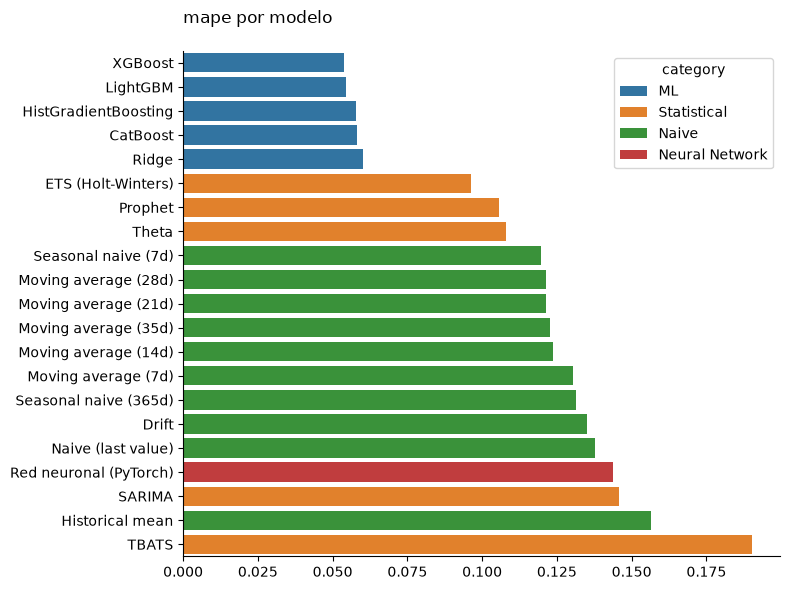

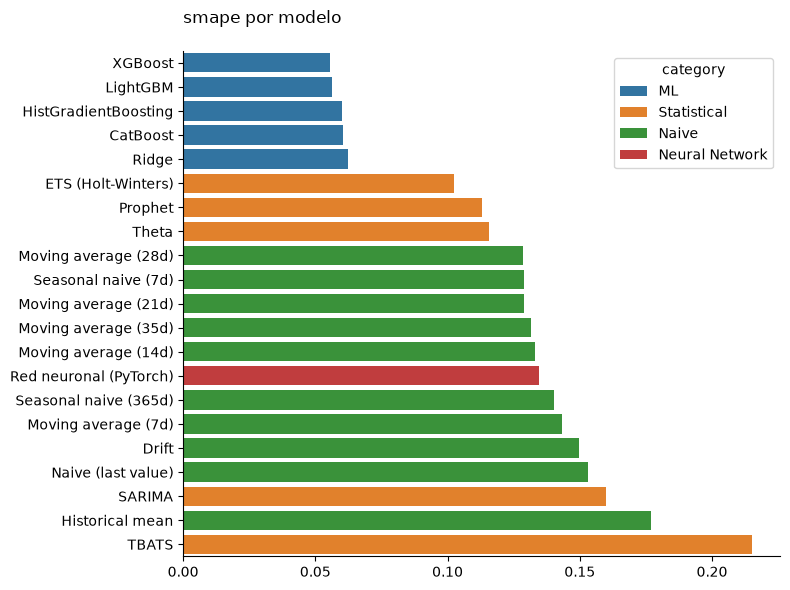

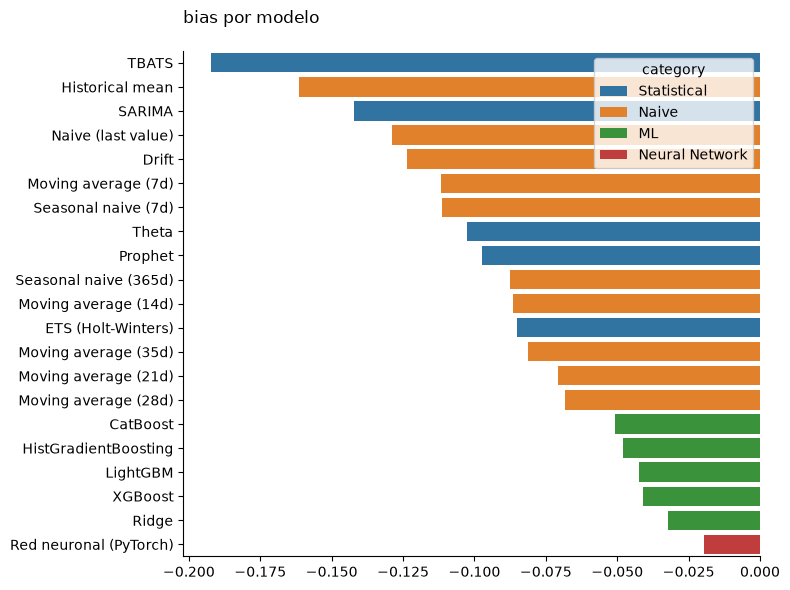

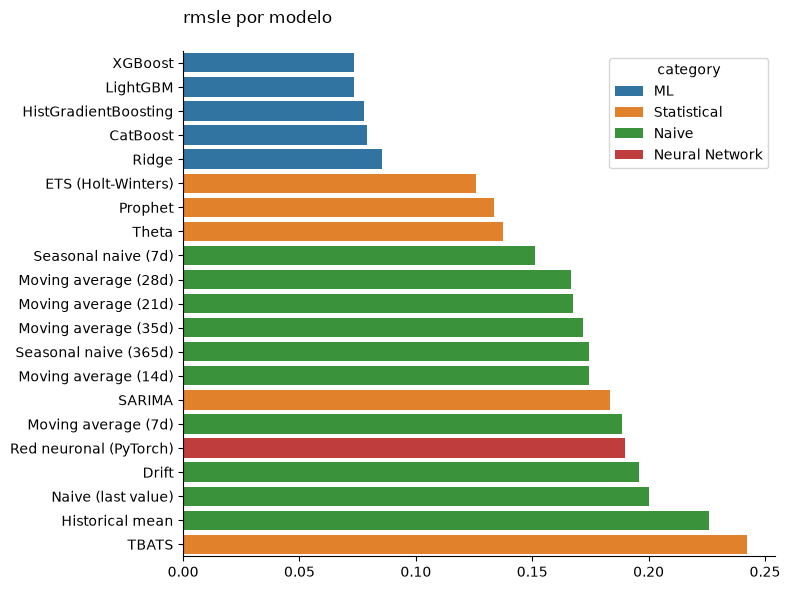

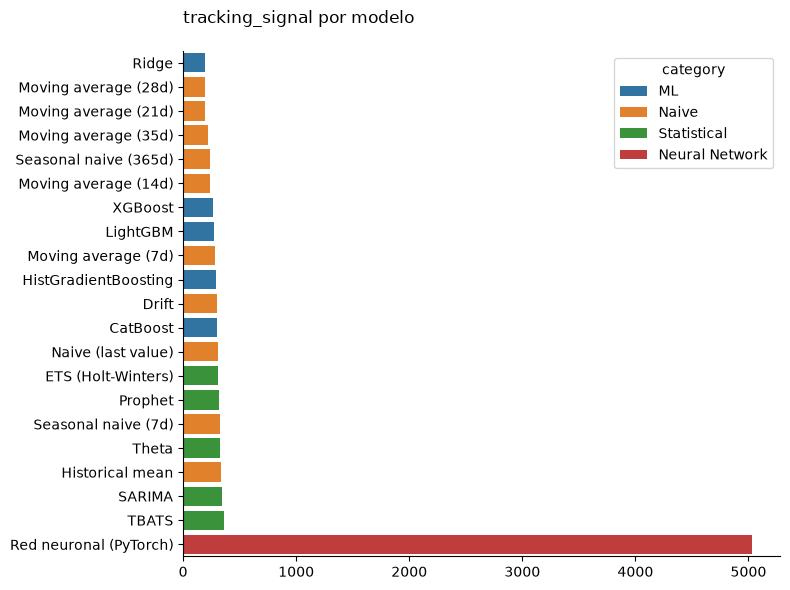

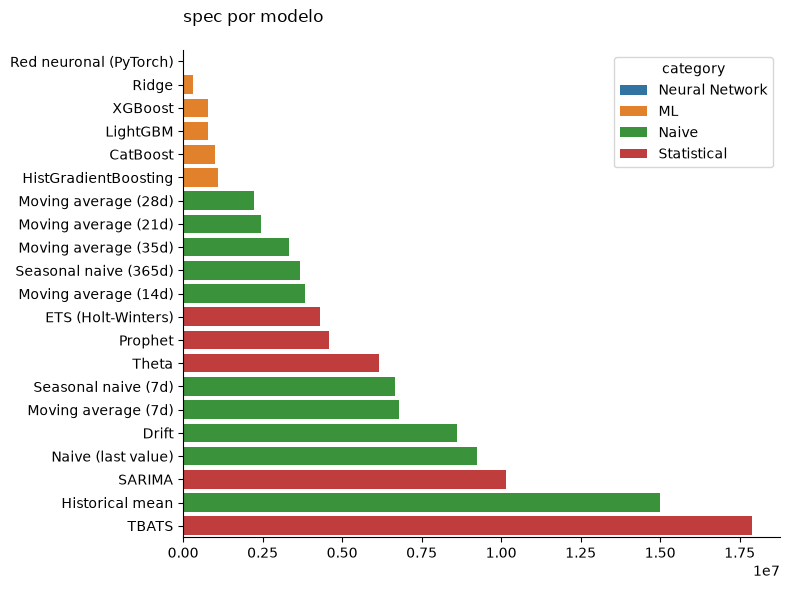

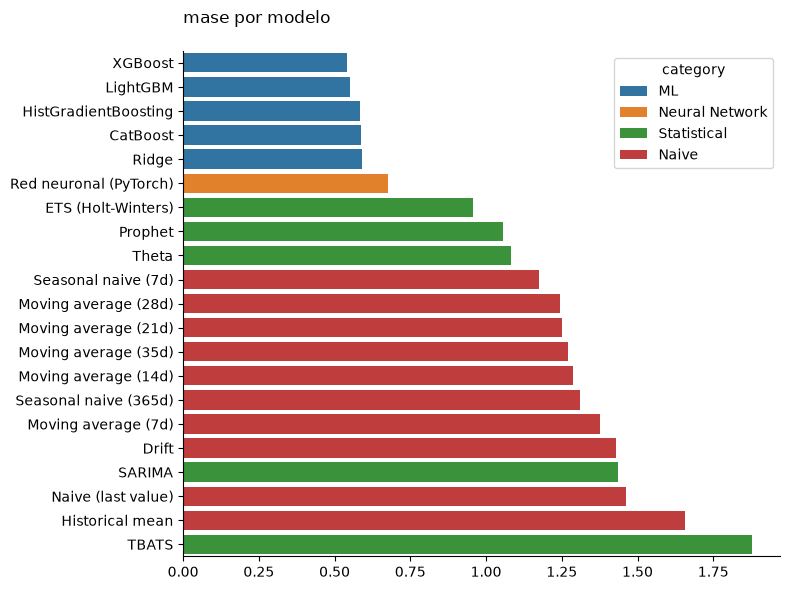

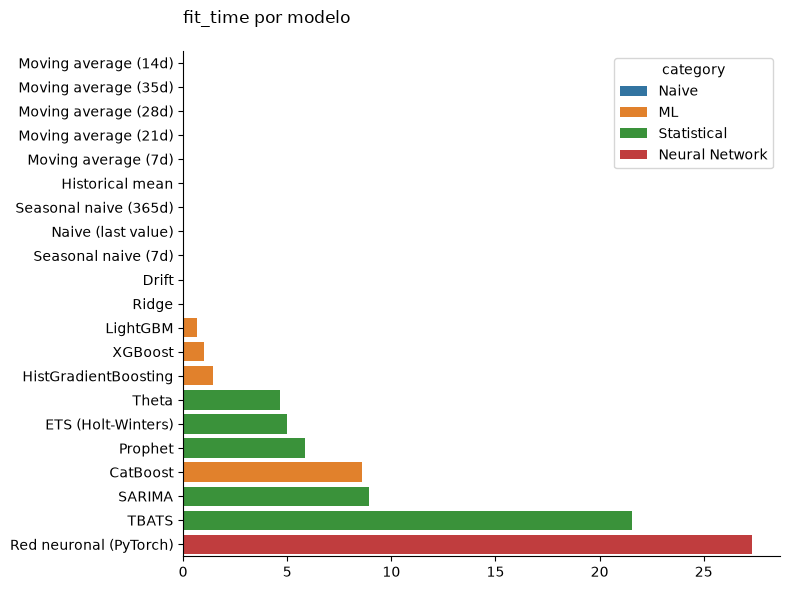

In [34]:
for col in ['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

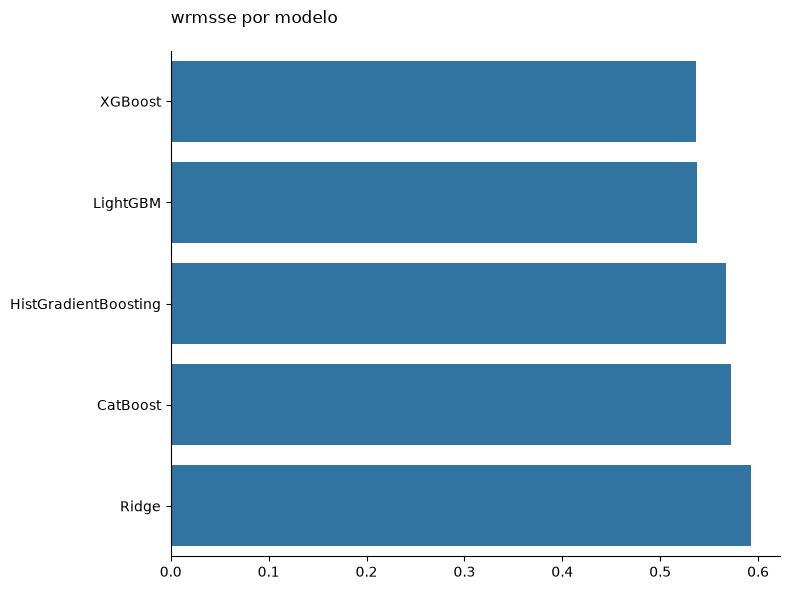

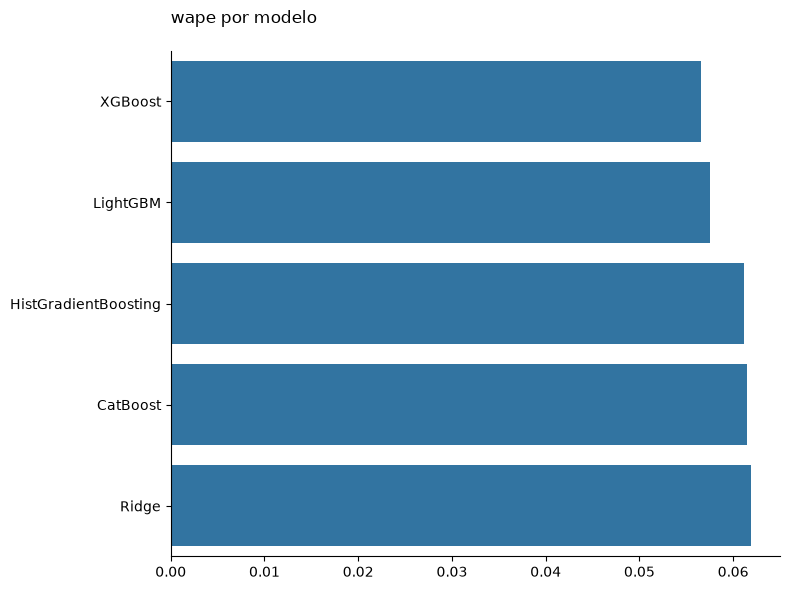

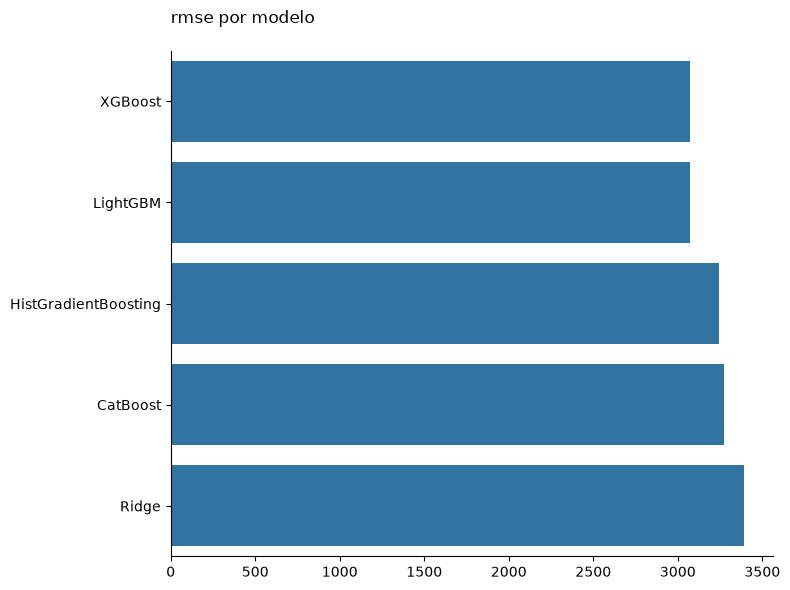

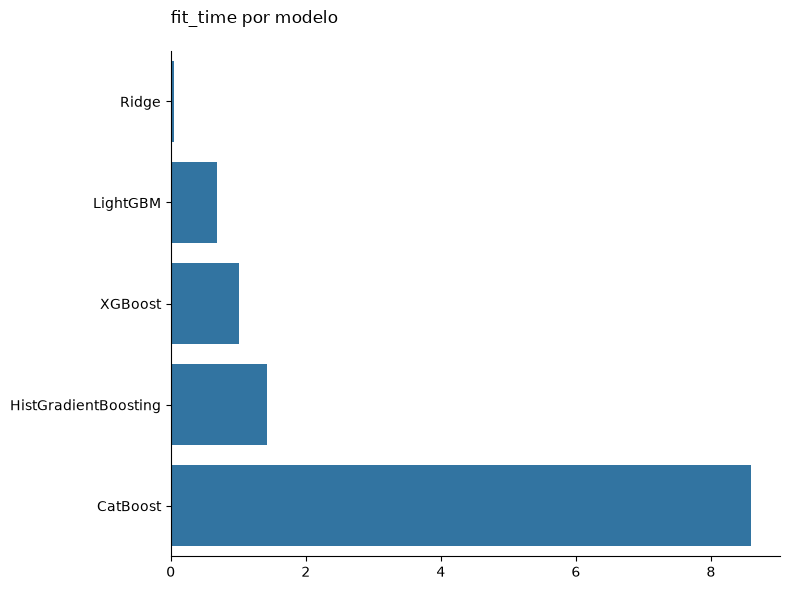

In [35]:
for col in ['wrmsse','wape','rmse', 'fit_time']:
    plot_barh_by_model(results_df.query('category == "ML"'), x=col, y="model", title=f"{col} por modelo")

# Selección de features

El resto del notebook usa LightGBM (velocidad, soporte nativo de categóricas, compatible con SHAP), así que la selección se hace sobre `lgbm_model`. Se comparan dos criterios de importancia (gain del árbol vs. permutation importance sobre validación) y luego se aplica una eliminación hacia atrás (backward elimination): se van descartando las features menos importantes mientras el WRMSSE de validación no empeore más allá de una tolerancia.

## Importancia por ganancia (gain)

In [36]:
importance_gain = (
    pd.Series(lgbm_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)
importance_gain.head(20)

lag28                              2.357972e+11
lag364                             2.783101e+10
lag182                             1.825573e+10
lag7                               1.530358e+10
day                                1.113672e+10
dayofweek                          1.045798e+10
lag1                               8.725674e+09
lag91                              6.175641e+09
price_change                       6.124590e+09
lag35                              5.468880e+09
price_vs_max                       4.166414e+09
days_to_closure                    4.156036e+09
lag14                              3.881110e+09
days_since_thanksgiving            2.435890e+09
avg_sell_price                     2.126374e+09
rolling_mean_lag28_window_size7    1.825018e+09
doy_cos                            1.461683e+09
event_type_1_enc                   1.397176e+09
days_since_newyear                 1.305190e+09
rolling_min_lag28_window_size7     1.275618e+09
dtype: float64

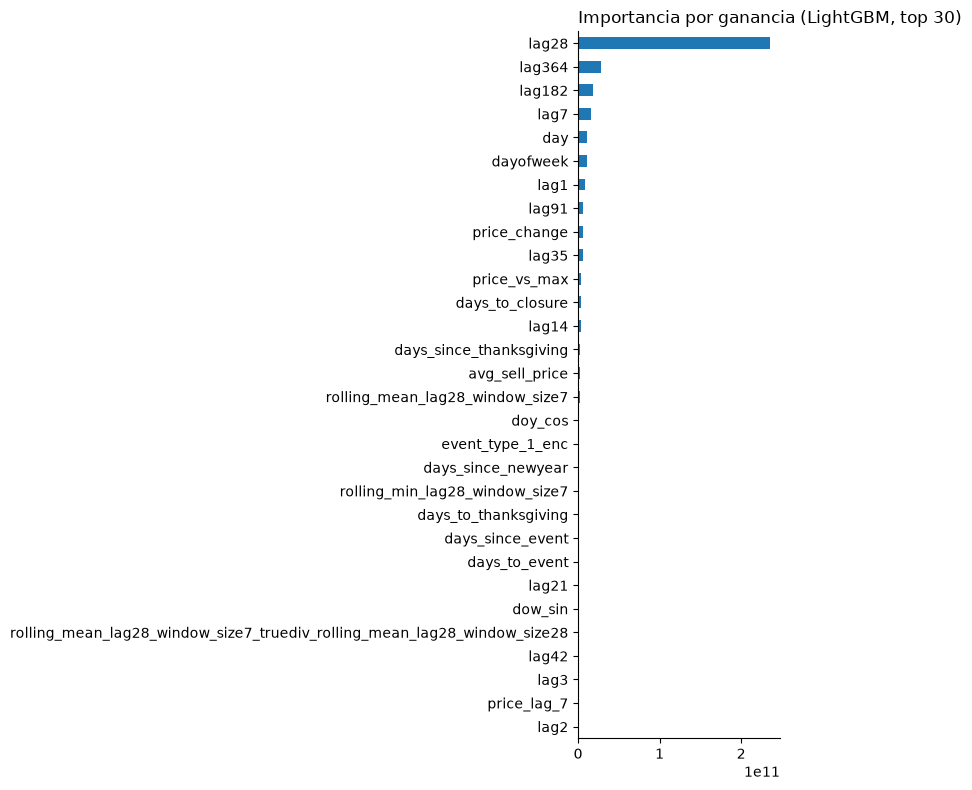

In [37]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_gain.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Importancia por ganancia (LightGBM, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Permutation importance

El gain puede sobreestimar features de alta cardinalidad o muy usadas para splits sin aportar demasiado al error final. La permutation importance mide directamente cuánto empeora el WAPE en validación al mezclar (shuffle) cada columna, así que es un criterio más fiel al desempeño real del modelo.

In [38]:
from src.modeling import compute_permutation_importance

importance_perm = compute_permutation_importance(
    lgbm_model, X_valid, y_valid, FEATURES,
    sample_size=15_000, n_repeats=10, random_state=RANDOM_STATE,
)
importance_perm.head(20)


lag28                                                       1113.360966
lag364                                                       814.507799
dayofweek                                                    492.127242
day                                                          365.929851
days_to_closure                                              274.209944
lag1                                                         257.692962
lag182                                                       254.126645
lag7                                                         110.358490
days_since_thanksgiving                                      106.296083
lag21                                                         94.482790
price_change                                                  79.747188
lag14                                                         50.732910
event_type_1_enc                                              50.587365
avg_sell_price                                                45

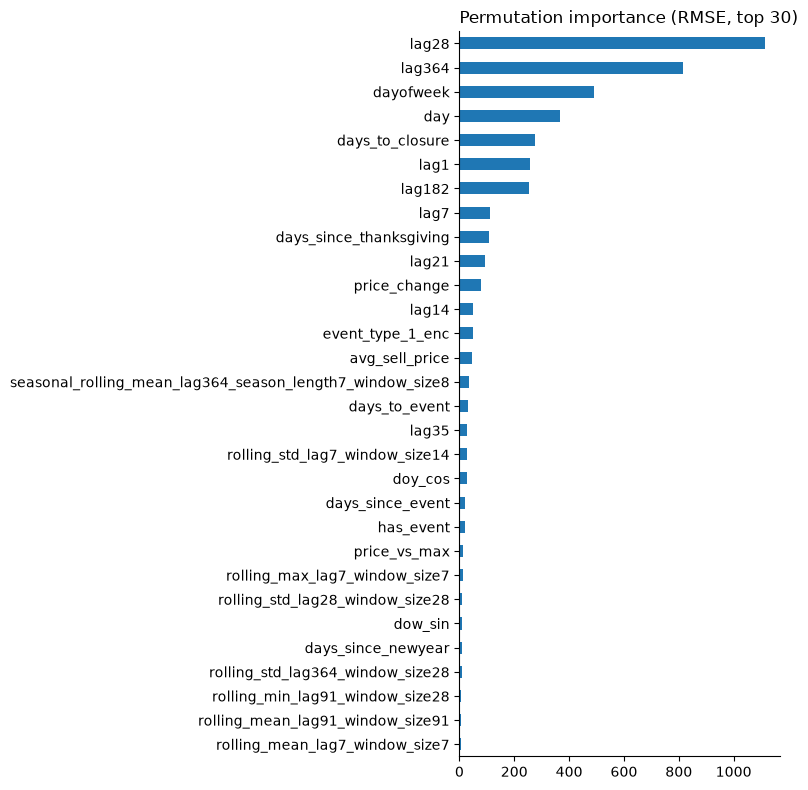

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_perm.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Permutation importance (RMSE, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Eliminación hacia atrás (backward elimination)

Se parte del ranking de permutation importance (de menor a mayor) y se intenta eliminar cada feature: si reentrenar sin ella no empeora el WRMSSE de validación más allá de `TOLERANCE`, se descarta definitivamente.

In [40]:
from src.modeling import backward_feature_selection

selected_features, final_wrmsse, log_df = backward_feature_selection(
    X_train, y_train, X_valid, train, valid,
    FEATURES, CATEGORICAL_FEATURES, importance_perm,
    tolerance=0.001, random_state=RANDOM_STATE,
)


2026-08-23 00:03:14.949 | INFO     | src.modeling.feature_selection:backward_feature_selection:80 - Baseline (104 features): WRMSSE=0.5373
2026-08-23 00:03:15.529 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'lag91' -> 103 features | WRMSSE=0.5246
2026-08-23 00:03:16.098 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:98 - mantiene: 'lag42' | WRMSSE empeoraría a 0.5328
2026-08-23 00:03:16.713 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'days_to_newyear' -> 102 features | WRMSSE=0.5187
2026-08-23 00:03:17.288 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'rolling_min_lag91_window_size91' -> 101 features | WRMSSE=0.5161
2026-08-23 00:03:17.804 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:98 - mantiene: 'rolling_std_lag28_window_size91' | WRMSSE empeoraría a 0.5206
2026-08-23 00:03:18.328 | WARNING  | src.modeling.fe

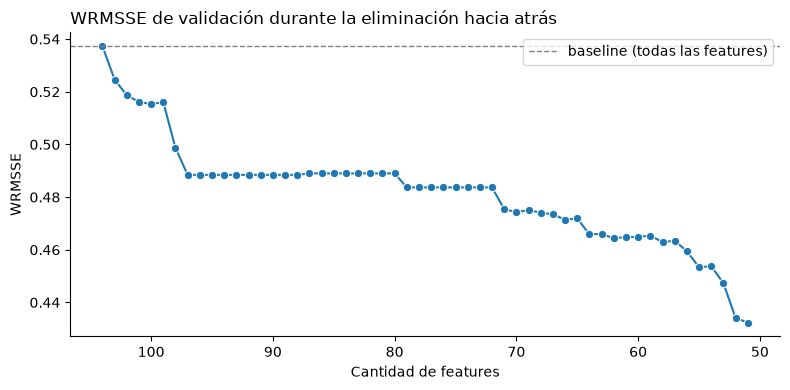

In [41]:
baseline_wrmsse = log_df.loc[log_df["removed"].isna(), "wrmsse"].iloc[0]

# Trayectoria real: baseline + solo las eliminaciones aceptadas, en orden
trajectory = log_df[log_df["accepted"]].sort_values("n_features", ascending=False)
baseline_wrmsse = trajectory["wrmsse"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(trajectory, x="n_features", y="wrmsse", marker="o", ax=ax)
ax.invert_xaxis()
ax.axhline(baseline_wrmsse, color="grey", linestyle="--", linewidth=1, label="baseline (todas las features)")
ax.set_title("WRMSSE de validación durante la eliminación hacia atrás", loc="left")
ax.set_xlabel("Cantidad de features")
ax.set_ylabel("WRMSSE")
ax.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

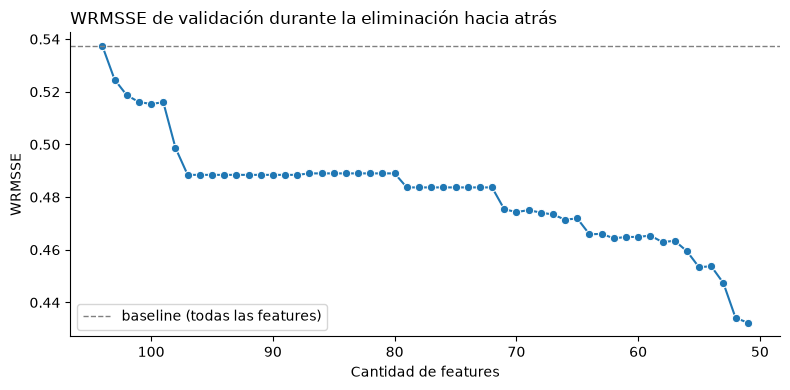

In [42]:
baseline_wrmsse = log_df.loc[log_df["removed"].isna(), "wrmsse"].iloc[0]

# Trayectoria real: baseline + solo las eliminaciones aceptadas, en orden
trajectory = log_df[log_df["accepted"]].sort_values("n_features", ascending=False)
baseline_wrmsse = trajectory["wrmsse"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(trajectory, x="n_features", y="wrmsse", marker="o", ax=ax)
ax.invert_xaxis()
ax.axhline(baseline_wrmsse, color="grey", linestyle="--", linewidth=1, label="baseline (todas las features)")
ax.set_title("WRMSSE de validación durante la eliminación hacia atrás", loc="left")
ax.set_xlabel("Cantidad de features")
ax.set_ylabel("WRMSSE")
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Features seleccionadas

Se fija `FEATURES` (y las variables derivadas `X_train`/`X_valid`/`X_test`/`CATEGORICAL_FEATURES`/`NUMERICAL_FEATURES`) al subconjunto seleccionado, para que el resto del notebook (modelo simple, SHAP, tuning con Optuna, modelo final) entrene sobre las features filtradas.

In [43]:
print(f"Features descartadas ({len(FEATURES) - len(selected_features)}): "
      f"{sorted(set(FEATURES) - set(selected_features))}")

FEATURES = selected_features
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in FEATURES]
NUMERICAL_FEATURES = [c for c in NUMERICAL_FEATURES if c in FEATURES]

X_train = X_train[FEATURES]
X_valid = X_valid[FEATURES]
X_test = X_test[FEATURES]

print(f"Features finales: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categóricas)")

Features descartadas (53): ['adi_expanding', 'cat_id', 'cv2_90', 'days_since_release', 'days_to_closure', 'days_to_newyear', 'days_to_thanksgiving', 'dept_id', 'dow_cos', 'doy_sin', 'event_name_1', 'event_name_2', 'event_type_1', 'event_type_2', 'event_type_2_enc', 'has_event', 'has_event_2', 'is_likely_stockout', 'is_month_end', 'is_month_start', 'is_store_closed', 'is_weekend', 'item_id', 'lag35', 'lag364', 'lag42', 'lag91', 'month', 'month_sin', 'pct_zero_28', 'pct_zero_90', 'price_lag_7', 'price_vs_mean', 'quarter', 'rolling_max_lag7_window_size14', 'rolling_max_lag91_window_size91', 'rolling_mean_lag364_window_size28', 'rolling_mean_lag365_window_size91', 'rolling_mean_lag7_window_size14', 'rolling_mean_lag91_window_size28', 'rolling_min_lag28_window_size91', 'rolling_min_lag7_window_size14', 'rolling_min_lag91_window_size91', 'rolling_std_lag28_window_size7', 'rolling_std_lag364_window_size91', 'rolling_std_lag7_window_size7', 'rolling_std_lag91_window_size28', 'seasonal_rolling_

# Modelo simple

In [44]:
from lightgbm import LGBMRegressor
import lightgbm as lgb
from src.evaluation import wape_metric, make_wrmsse_metric

wrmsse_metric = make_wrmsse_metric(train, valid)


In [45]:
model = LGBMRegressor(
    objective="rmse",
)

t0 = time.perf_counter()
model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=[wrmsse_metric,],
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features)", model.predict(X_valid), fit_time=fit_time, category="ML")

Training until validation scores don't improve for 100 rounds
[10]	valid_0's rmse: 5246.44	valid_0's wrmsse: 0.870424
[20]	valid_0's rmse: 3969.66	valid_0's wrmsse: 0.630055
[30]	valid_0's rmse: 3447.77	valid_0's wrmsse: 0.5277
[40]	valid_0's rmse: 3199.2	valid_0's wrmsse: 0.487588
[50]	valid_0's rmse: 3028.67	valid_0's wrmsse: 0.463357
[60]	valid_0's rmse: 2920.77	valid_0's wrmsse: 0.449648
[70]	valid_0's rmse: 2839.65	valid_0's wrmsse: 0.43841
[80]	valid_0's rmse: 2787.43	valid_0's wrmsse: 0.434056
[90]	valid_0's rmse: 2761.43	valid_0's wrmsse: 0.433048
[100]	valid_0's rmse: 2733.69	valid_0's wrmsse: 0.432327
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 2733.69	valid_0's wrmsse: 0.432327
Evaluated only: rmse


2026-08-23 00:05:31.661 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - LightGBM (selected features) [ML] | WAPE: 4.54% | WRMSSE: 0.4323 | MAE: 1790.578 | RMSE: 2473.078 | MAPE: 4.35% | SMAPE: 4.44% | Bias: -2.44% | RMSLE: 0.0591 | TS: 196.00 | SPEC: 279683.674 | MASE: 0.4342 | fit: 1.68s


{'model': 'LightGBM (selected features)',
 'category': 'ML',
 'wape': 0.04544008711871646,
 'wrmsse': 0.43232680973386123,
 'mae': 1790.5783352916224,
 'rmse': 2473.077755997386,
 'mape': 0.04347121793804973,
 'smape': 0.044390835605381686,
 'bias': -0.024401283437287508,
 'rmsle': 0.05912906904890802,
 'tracking_signal': 196.00465182518164,
 'spec': 279683.67404800386,
 'mase': 0.4341798140338085,
 'fit_time': 1.6816648639978666}

## Explicación modelo

In [46]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(2000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)

In [47]:
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                                              feature  mean_abs_shap
21                                              lag28    3475.772182
3                                           dayofweek    1425.232377
18                                               lag7     972.115336
2                                                 day     791.336438
23                                             lag182     732.896952
15                                               lag1     705.691888
22                                              lag56     363.813582
19                                              lag14     341.477547
6                                    days_since_event     301.328646
20                                              lag21     242.637022
9                                             dow_sin     231.282808
5                                        price_vs_max     207.479010
13                            days_since_thanksgiving     174.835038
7                                 

### Importancia global de features

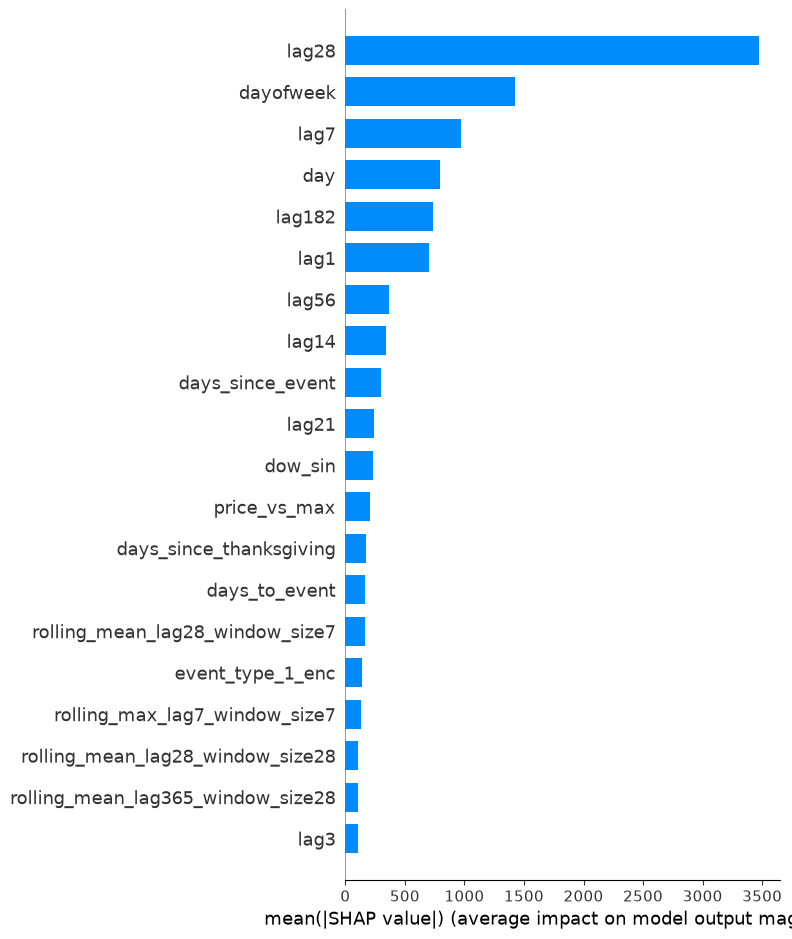

In [48]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

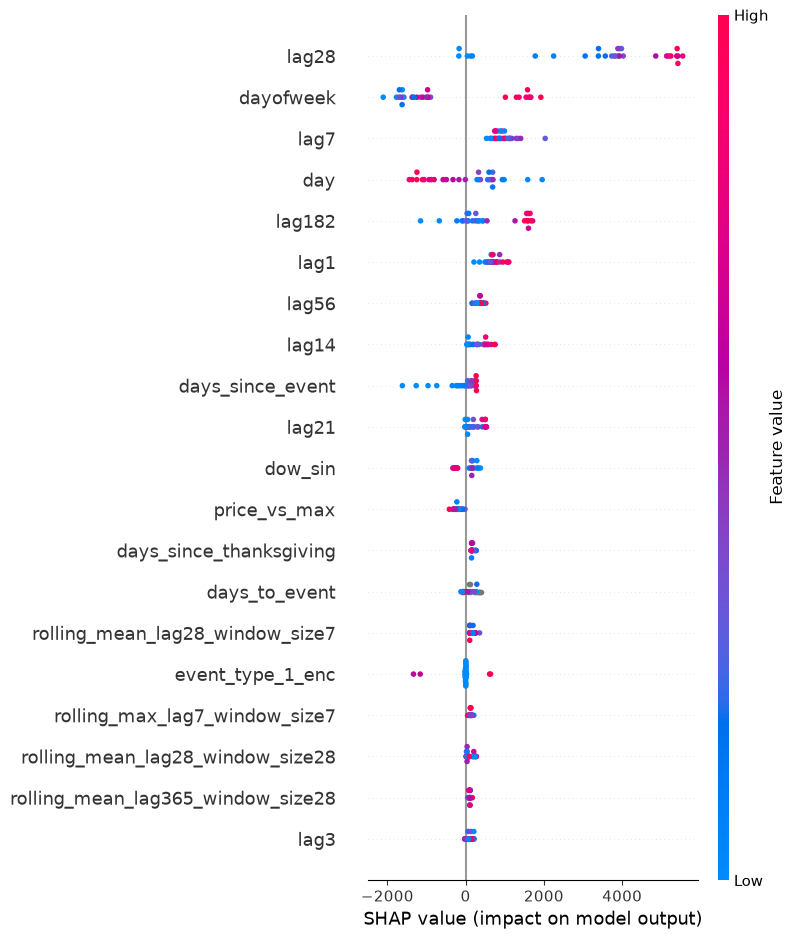

In [49]:
shap.summary_plot(shap_values, X_shap)

### Dependencia por feature

Feature más importante: lag28


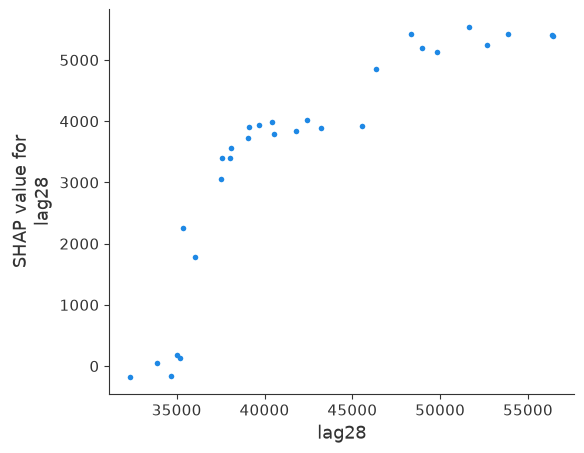

In [50]:
top_feature = X_shap.columns[np.argsort(-np.abs(shap_values).mean(axis=0))[0]]
print(f"Feature más importante: {top_feature}")

shap.dependence_plot(top_feature, shap_values, X_shap, interaction_index=None)

# Predicciones

In [51]:
from src.evaluation import explain_prediction


In [52]:
from src.evaluation import plot_forecast


In [53]:
from src.evaluation import analizar_prediccion as _analizar_prediccion

def analizar_prediccion(agg_id, date=None, max_display=10):
    return _analizar_prediccion(
        test, X_test, df_pred, TARGET, agg_id,
        date=date, max_display=max_display, explainer=explainer,
    )


In [54]:
from src.evaluation.metrics import build_predictions_report

metrics_test, df_pred = build_predictions_report(train, test, y_test, model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test['wrmsse']:.4f}")

Test WAPE: 8.31%
Test WRMSSE: 0.7975


In [ ]:
#from src.evaluation.metrics import build_series_metrics

#df_metrics = build_series_metrics(train, df_pred, target_col=TARGET, weight_level=["date"])
#df_metrics.head(10)

In [ ]:
#df_pred.query('agg_id == "FOODS_3_FOODS_CA_3_CA"').nlargest(10, 'wape')

In [ ]:
#_analizar_prediccion('TOTAL', '2016-05-16',)

# Modelo optimizado

In [59]:
import optuna
from optuna.integration import LightGBMPruningCallback
import lightgbm as lgb
import numpy as np

In [60]:
import lightgbm as lgb
import numpy as np
import optuna
from optuna.integration import LightGBMPruningCallback

In [61]:
def objective(trial):
    model = lgb.LGBMRegressor(
        objective="rmse",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        n_estimators=1500,
        num_leaves=trial.suggest_int("num_leaves", 31, 255),
        max_depth=trial.suggest_int("max_depth", 5, 10),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 5, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 5, log=True),
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="rmse",
        categorical_feature=CATEGORICAL_FEATURES,
        callbacks=[
            lgb.early_stopping(30, first_metric_only=True, verbose=False),
            LightGBMPruningCallback(trial, "rmse"),
        ],
    )
    y_pred = model.predict(X_valid, num_iteration=model.best_iteration_)
    _, final_wrmsse, _ = wrmsse_metric(y_valid, y_pred)
    return final_wrmsse

In [62]:
study = optuna.create_study(
    study_name=f"study_{LEVEL}", 
    direction="minimize",
    storage="sqlite:///../artifacts/optuna_study.db",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        seed=42,
       #multivariate=True,
        #group=True,
    ),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10, n_startup_trials=5),
)

study.optimize(
    objective,
    n_trials=1_000,
    timeout=60 * 3,
    show_progress_bar=True,
)

best_trial = study.best_trial
print(f"Mejor WRMSSE: {best_trial.value:.4f}")
print("Mejores hiperparámetros:", best_trial.params)

[I 2026-08-23 00:06:50,842] A new study created in RDB with name: study_level_01_daily_total


  0%|          | 0/1000 [00:00<?, ?it/s]

[I 2026-08-23 00:07:15,654] Trial 0 finished with value: 0.5737795208837903 and parameters: {'learning_rate': 0.054816785328198704, 'num_leaves': 244, 'max_depth': 9, 'min_child_samples': 128, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.0016400214911202306, 'reg_lambda': 1.599409170128044}. Best is trial 0 with value: 0.5737795208837903.
[I 2026-08-23 00:08:24,630] Trial 1 finished with value: 0.5093324376039731 and parameters: {'learning_rate': 0.07893736353172352, 'num_leaves': 190, 'max_depth': 5, 'min_child_samples': 195, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.004705059281907645, 'reg_lambda': 0.004768785415482609}. Best is trial 1 with value: 0.5093324376039731.
[I 2026-08-23 00:09:19,200] Trial 2 finished with value: 0.48549124403888666 and parameters: {'learning_rate': 0.048952790869270256, 'num_leaves': 149, 'max_depth': 7, 'min_child_samples': 72, 'subsample': 0.8447411578889518, 'colsa

# Modelo final

In [63]:
model_params = best_trial.params

final_model = lgb.LGBMRegressor(
    objective="rmse",
    n_estimators=1000,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    subsample_freq=1,
    **model_params,
)

t0 = time.perf_counter()
final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=wrmsse_metric,
    categorical_feature=CATEGORICAL_FEATURES,
    callbacks=[
        lgb.early_stopping(50, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features | Optuna)", final_model.predict(X_valid), fit_time=fit_time, category="ML")
final_model.booster_.save_model(f"../artifacts/{LEVEL}_final_model.txt")

Training until validation scores don't improve for 50 rounds
[10]	valid_0's rmse: 6899.14	valid_0's wrmsse: 1.16835
[20]	valid_0's rmse: 5558.78	valid_0's wrmsse: 0.92516
[30]	valid_0's rmse: 4795.04	valid_0's wrmsse: 0.783083
[40]	valid_0's rmse: 4348.49	valid_0's wrmsse: 0.697791
[50]	valid_0's rmse: 4059.69	valid_0's wrmsse: 0.641499
[60]	valid_0's rmse: 3869.35	valid_0's wrmsse: 0.606904
[70]	valid_0's rmse: 3747.89	valid_0's wrmsse: 0.584634
[80]	valid_0's rmse: 3656.8	valid_0's wrmsse: 0.568242
[90]	valid_0's rmse: 3586.53	valid_0's wrmsse: 0.556356
[100]	valid_0's rmse: 3559.97	valid_0's wrmsse: 0.551541
[110]	valid_0's rmse: 3523.95	valid_0's wrmsse: 0.545503
[120]	valid_0's rmse: 3481.14	valid_0's wrmsse: 0.538613
[130]	valid_0's rmse: 3447.34	valid_0's wrmsse: 0.533723
[140]	valid_0's rmse: 3413.19	valid_0's wrmsse: 0.527941
[150]	valid_0's rmse: 3393.63	valid_0's wrmsse: 0.525725
[160]	valid_0's rmse: 3368.73	valid_0's wrmsse: 0.522213
[170]	valid_0's rmse: 3340.99	valid_0's

2026-08-23 00:10:24.516 | INFO     | src.evaluation.metrics:evaluate_predictions:326 - LightGBM (selected features | Optuna) [ML] | WAPE: 5.23% | WRMSSE: 0.4855 | MAE: 2059.213 | RMSE: 2777.199 | MAPE: 4.98% | SMAPE: 5.14% | Bias: -3.88% | RMSLE: 0.0670 | TS: 270.88 | SPEC: 734557.977 | MASE: 0.4993 | fit: 30.44s


[680]	valid_0's rmse: 2987.49	valid_0's wrmsse: 0.487982
Early stopping, best iteration is:
[632]	valid_0's rmse: 2981.74	valid_0's wrmsse: 0.485491
Evaluated only: rmse


## Resultados finales

In [64]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse").query('wape <= 0.15')
results_df

,model,category,wape,wrmsse,mae,rmse,mape,smape,bias,rmsle,tracking_signal,spec,mase,fit_time
21,LightGBM (selected features),ML,0.045440,0.432327,1790.578335,2473.077756,0.043471,0.044391,-0.024401,0.059129,196.004652,2.796837e+05,0.434180,1.681665
22,LightGBM (selected features | Optuna),ML,0.052257,0.485491,2059.213444,2777.199029,0.049751,0.051370,-0.038782,0.066956,270.878550,7.345580e+05,0.499319,30.435922
16,XGBoost,ML,0.056522,0.537014,2227.272078,3071.930608,0.053698,0.055645,-0.040884,0.073412,264.016556,7.750957e+05,0.540069,1.008379
15,LightGBM,ML,0.057529,0.537321,2266.927040,3073.682872,0.054380,0.056315,-0.042399,0.073439,269.006396,7.752721e+05,0.549685,0.680079
18,HistGradientBoosting,ML,0.061134,0.567333,2408.992507,3245.364130,0.057812,0.060125,-0.048145,0.077920,287.449234,1.088865e+06,0.584133,1.418901
17,CatBoost,ML,0.061434,0.572305,2420.803986,3273.807620,0.058032,0.060590,-0.050830,0.078957,301.999091,1.000063e+06,0.586997,8.593174
19,Ridge,ML,0.061901,0.592753,2439.210871,3390.778500,0.060286,0.062392,-0.032332,0.085342,190.646066,2.975035e+05,0.591460,0.054508
20,Red neuronal (PyTorch),Neural Network,0.100282,0.664811,56.451958,101.112627,0.143616,0.134509,-0.019733,0.189865,5027.640505,2.481627e+04,0.677905,27.297045
11,ETS (Holt-Winters),Statistical,0.100163,0.859665,3946.952076,4917.616379,0.096371,0.102319,-0.085113,0.125627,310.157372,4.319266e+06,0.957058,4.989558
14,Prophet,Statistical,0.110623,0.921947,4359.142045,5273.895740,0.105629,0.113014,-0.097516,0.133447,321.751839,4.583947e+06,1.057006,5.865139


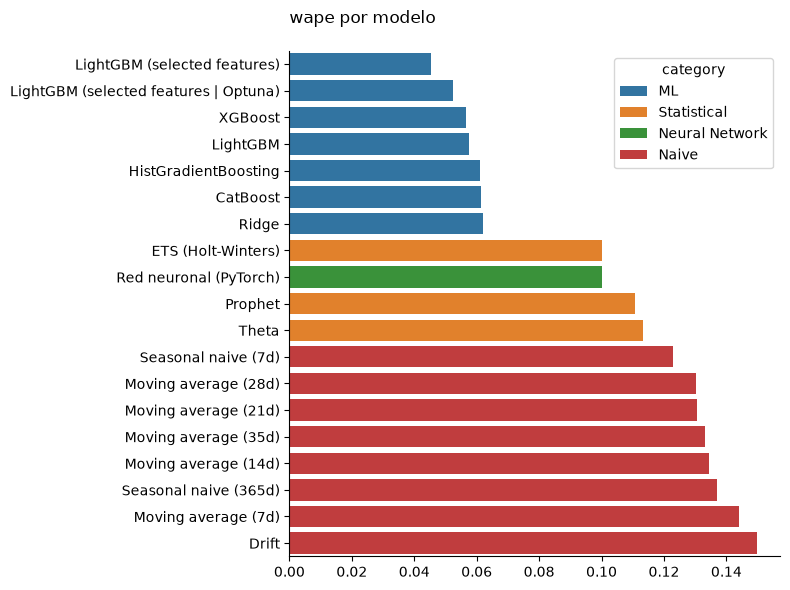

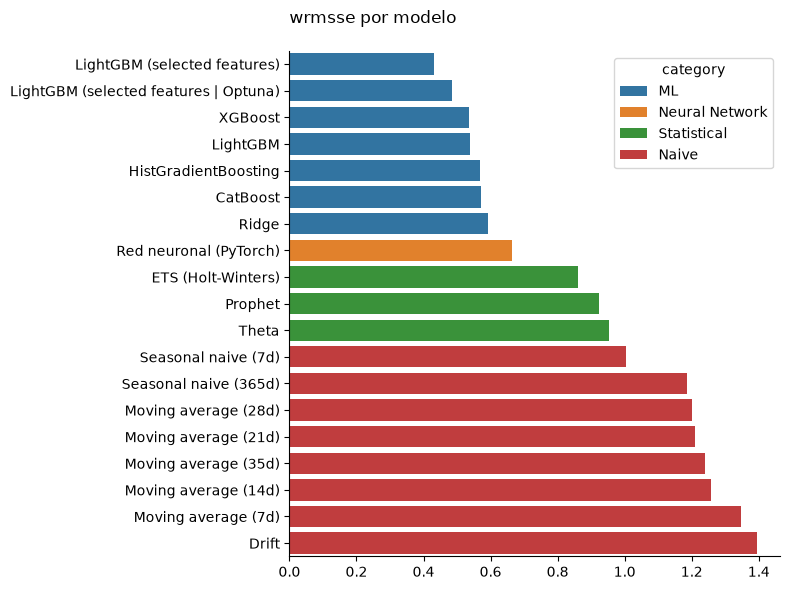

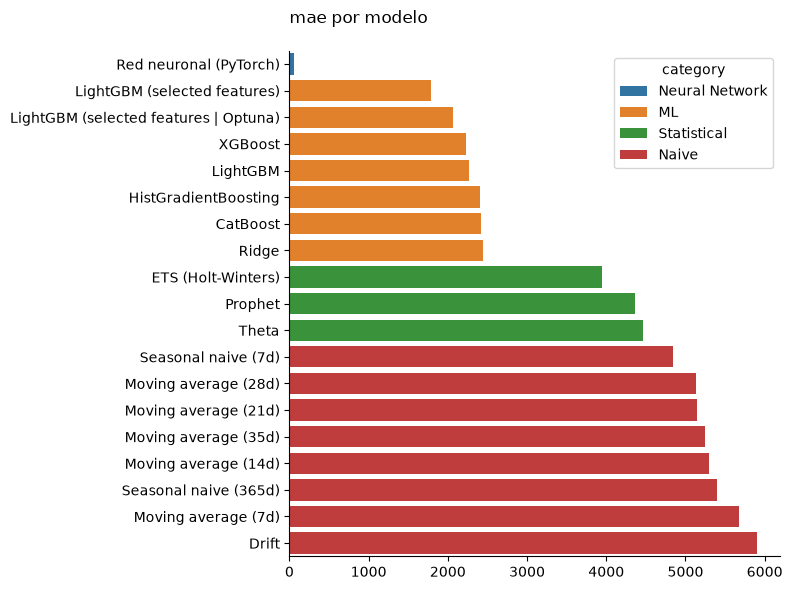

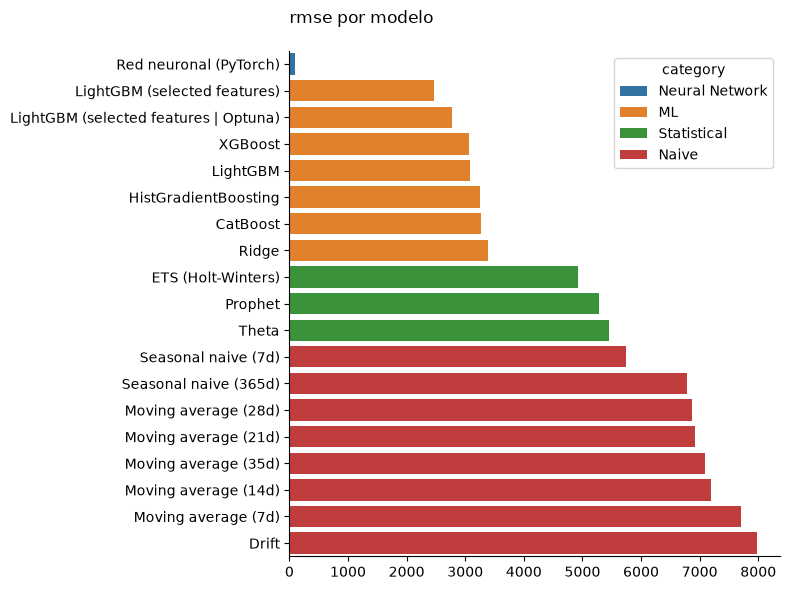

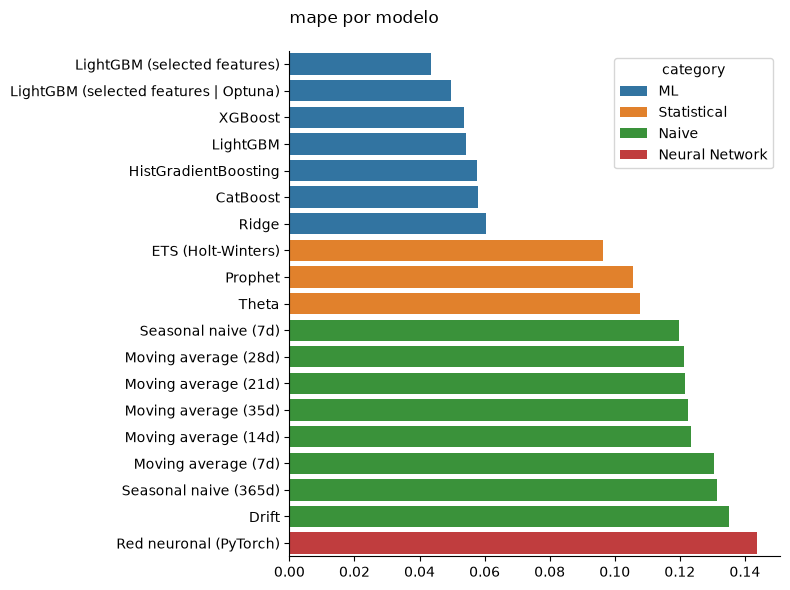

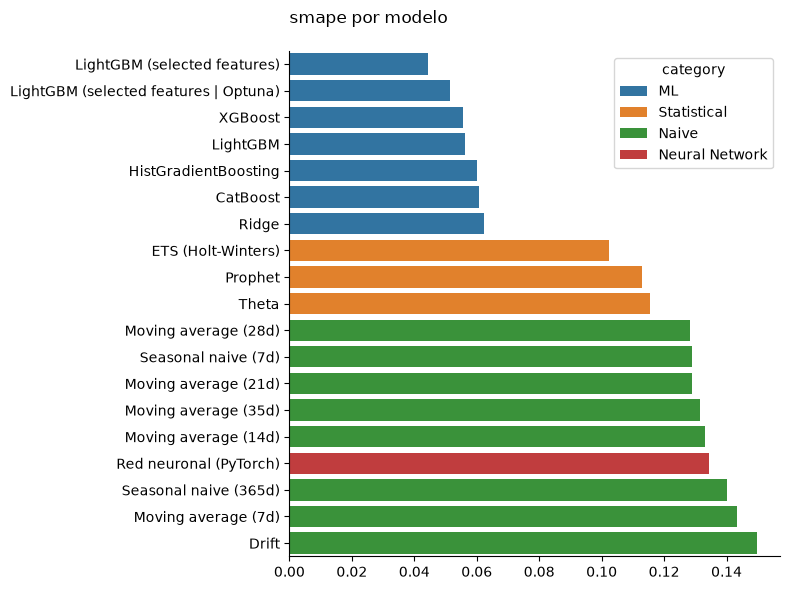

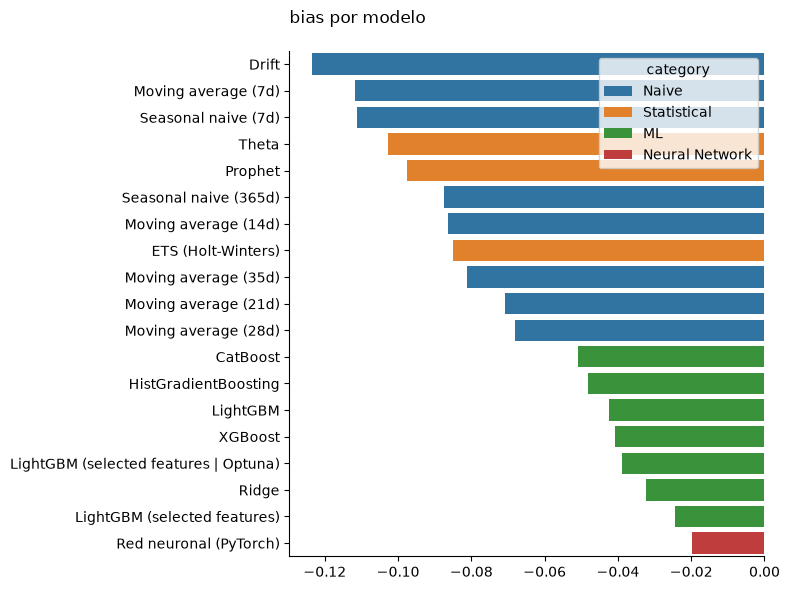

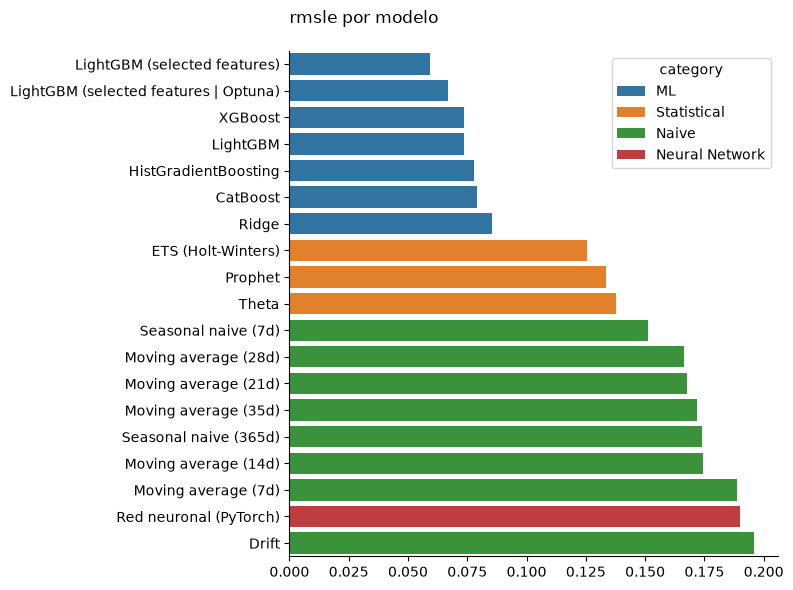

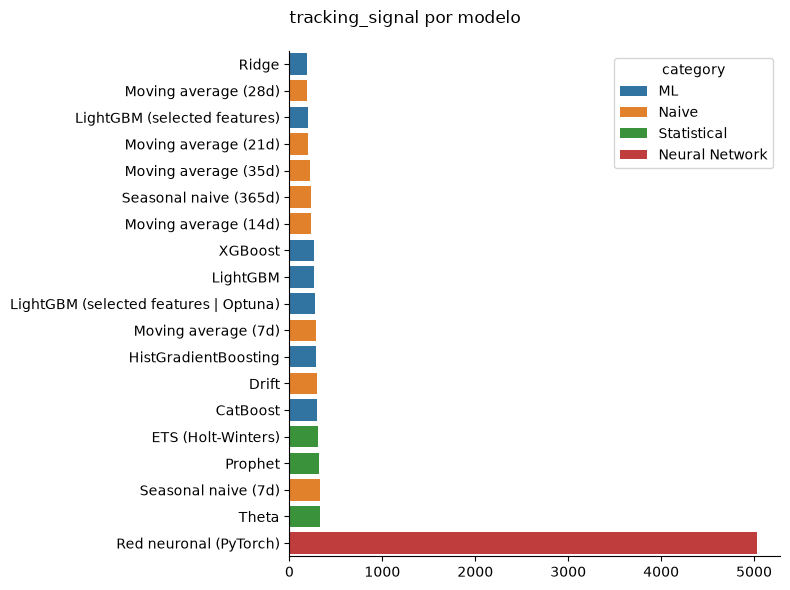

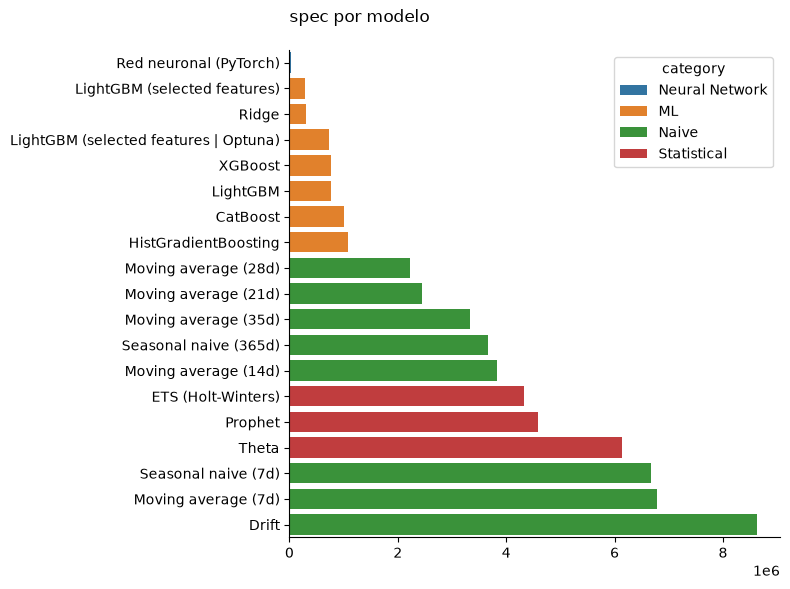

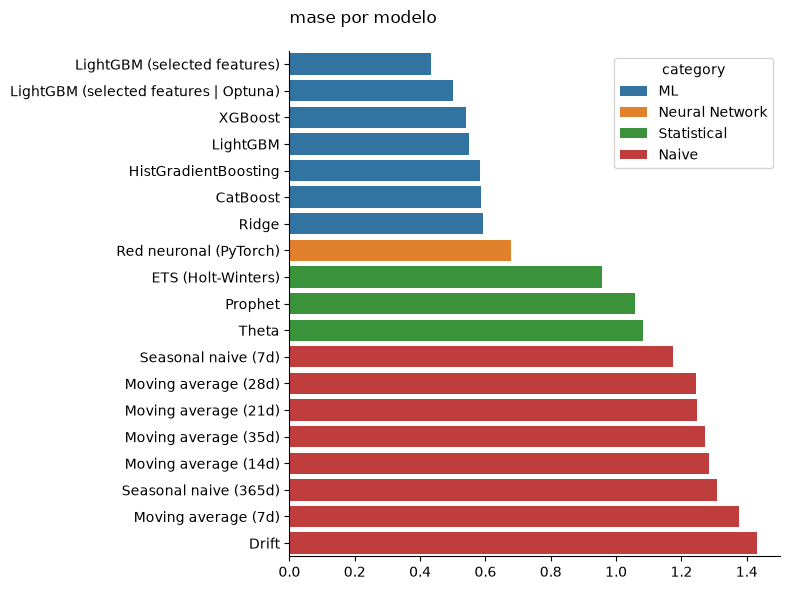

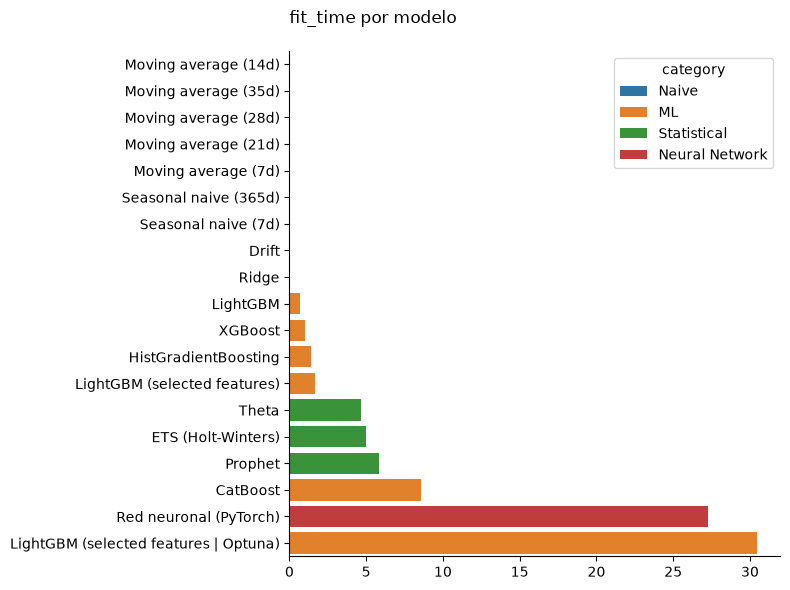

In [65]:
for col in ['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

# Exploración modelo final

In [66]:
metrics_test_final, df_pred = build_predictions_report(train, test, y_test, final_model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

Test WAPE: 10.46%
Test WRMSSE: 0.9699


In [70]:
# from src.evaluation.metrics import build_series_metrics

# df_metrics = build_series_metrics(train, df_pred, target_col=TARGET, weight_level=["date"])
# df_metrics.head(10)

In [71]:
# df_pred.query('agg_id == "FOODS_3_FOODS_CA_3_CA"').nlargest(10, 'wape')

In [72]:
# analizar_prediccion('FOODS_3_FOODS_CA_3_CA', '2016-05-15',)

# Exportar

In [73]:
import joblib

feature_importance = (
    pd.Series(final_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)

artifact = {
    # modelo y datos de trabajo
    "level": LEVEL,
    "metrics_results": results_df,
    "model": final_model,
    "model_params": model_params,
    "X_train": X_train,
    "y_train": y_train,
    "X_valid": X_valid,
    "y_valid": y_valid,
    "X_test": X_test,
    "y_test": y_test,
    "train": train,
    "valid": valid,
    "test": test,
    # features y columnas
    "features": FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "numerical_features": NUMERICAL_FEATURES,
    "id_cols": ID_COLS,
    "leaky_cols": LEAKY_COLS,
    "target": TARGET,
    "feature_importance": feature_importance,
    # predicciones y métricas del modelo final (test)
    "df_pred": df_pred,
    "df_metrics": df_metrics,
    # comparación de todos los modelos probados (validación)
    "model_results": model_results,
    "results_df": results_df,
    #"series_metrics_valid": series_metrics_df,
    # metadatos
    "wape_valid": model_results[-1]["wape"],
    "wrmsse_valid": model_results[-1]["wrmsse"],
    "wape_test": metrics_test_final["wape"],
    "wrmsse_test": metrics_test_final["wrmsse"],
    "train_start": str(first_date.date()),
    "valid_start": str(valid_start.date()),
    "test_start": str(test_start.date()),
}

artifact_path = f"../artifacts/{LEVEL}_artifact.pkl"
joblib.dump(artifact, artifact_path)
print(f"Artifact guardado en {artifact_path}")

Artifact guardado en ../artifacts/level_01_daily_total_artifact.pkl
